# Multi-GEOFF Experiment 2 — Validating the connection maturity stages

Experiment 3's Variant 2 will only let a newly generated connection originate from a **mature**
unit, where maturity is built from per-connection stages. The
[plan](multi_geoff_experiment_plan.md) calls that rule "a first idea [that] may not be a good
one", so this notebook validates it *before* Experiment 3 depends on it, on a problem where good
and bad connectivity is known by construction.

### The stages

* A connection is **nascent** when it is created.
* It enters **growth** when its weight crosses the jitter threshold — the point at which the
  weight is no longer plausibly a useless connection jittering around 0.
* It becomes **mature** when, while in growth, its Autostep gradient trace `h` crosses zero.

Each hidden and output unit keeps a trace `v` of its squared per-unit error over its incoming
weights, plus that trace's occupancy `c`. From them come the two thresholds:
$J_h = \tfrac{1}{2}\sqrt{\alpha_i v}$ (h is jitter-sized when $h_i^2 < \alpha_i v / 4$) and
$J_w = \sqrt{\alpha_i v / c}$, which is $2 J_h$ on the bias-corrected trace. Growth is unreachable
until $c > 0.5$, otherwise `v` starts at 0 and every connection would clear a zero threshold
immediately. The implementation is in `connection_stages.py`, shared with Experiment 3.

### The setup

Experiment 1a's construction exactly: 2-task non-stationary multi-GEOFF, 64 hidden units, a
block-sparse base structure with ⅓ of hidden units additionally connected to the other task's
outputs and ⅓ to its inputs. Every connection therefore carries a ground-truth useful / useless
label. Training is Experiment 1's — Autostep **Variant B** (`squared_inputs`), initial step-size
1e-6, and the meta step-size chosen in Experiment 1.

Everything is run in **two configurations**: with subgradient L1 at 0.01, which is what the plan
specifies and what Experiment 3 will use, and **without L1 at all**. L1 is entangled with both
halves of the stage rule — it holds weights far below the growth threshold, and its limit cycle
flips weight signs on ~99% of steps, which is exactly what the maturity and prune tests key on —
so the no-L1 run is the control that says whether a failure belongs to the rule or to the
regularizer.

**No pruning and no generation here** — the traces and stages are computed alongside training and
change nothing about it.

### The reset protocol

Stages are only interesting for *new* connections, and this network's connections are all as old
as the run. So from the halfway point, randomly chosen connections are **reset**: weight → 0,
step-size → 1e-6, `h` → 0, stage → nascent. A reset connection is indistinguishable from a freshly
generated one except that we know its label. Every check below is over reset connections.

In [1]:
import logging
import os
import sys
from dataclasses import dataclass

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import optax
import pandas as pd
import seaborn as sns
from matplotlib.colors import BoundaryNorm, ListedColormap
from omegaconf import OmegaConf
from scipy import stats

from mlflow_sweeper import SweepConfig, run_sweep, delete_sweep

from phd.jax_core.optimizers.idbd import IDBDState, optax_idbd
from phd.jax_core.tasks.multi_geoff import MultiGEOFFTask, perturbation_period
from phd.jax_core.utils import stack_pytrees, tree_replace
from phd.research_utils.scripts.mlflow_download import download_experiment
from phd.research_utils.analysis.analysis_utils import load_experiment_data, get_color_palette

NOTEBOOK_DIR = os.path.abspath('.')
if NOTEBOOK_DIR not in sys.path:      # make the sibling modules importable
    sys.path.insert(0, NOTEBOOK_DIR)

from masked_mlp import (
    INACTIVE, USEFUL, USELESS, MaskedTwoLayerMLP, block_sparse_masks, connection_labels,
    contaminate_masks, gather_at, masked_quantiles, slot_ids, subsample_indices, thirds_group_ids,
)
from connection_stages import (
    GROWTH, MATURE, NASCENT, NEVER, STAGE_NAMES, TRACE_K, deltas_from_perturbation_grads,
    init_stage_state, jitter_thresholds, perturbed_forward, prune_test, reset_connections_at,
    sample_reset_schedule, update_stage_state, zero_perturbations,
)
from experiment_logging import (
    ci_halfwidth, load_traces, log_curves, plot_learning_curve, save_traces,
)

sns.set_theme('notebook', 'white')
%matplotlib inline

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Every problem and learner constant is Experiment 1's, unchanged, so that this run is Experiment
1a + L1 with bookkeeping bolted on. The two settled outcomes of Experiment 1 are pinned here:
**Variant B** (`squared_inputs`) as the Autostep variant, and the meta step-size its step-1
reliability check chose.

Set `EXP2_SMOKE=1` in the environment to run everything end to end in seconds against local
sqlite stores — the fast validation path for edits to this notebook. It writes to a separate
MLflow experiment, so it cannot pollute the real results.

In [2]:
SMOKE_TEST = bool(int(os.environ.get('EXP2_SMOKE', '0')))

EXPERIMENT = 'multi-geoff-experiment-2' + ('-smoke' if SMOKE_TEST else '')
DATA_DIR = os.path.join(NOTEBOOK_DIR, 'data')
SWEEP_OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, 'sweep_output')
OUTPUT_DIR = os.path.join(NOTEBOOK_DIR, 'output')      # only used by the local-store fallback

for _dir in (DATA_DIR, SWEEP_OUTPUT_DIR, OUTPUT_DIR):
    os.makedirs(_dir, exist_ok=True)

# Default to the shared PostgreSQL server, falling back to local sqlite files if the environment
# does not define it. The env vars are only ever read here — never assigned — so running this
# notebook cannot repoint the session's tracking server.
USE_LOCAL_STORES = SMOKE_TEST

if USE_LOCAL_STORES:
    MLFLOW_URI = f"sqlite:///{os.path.join(OUTPUT_DIR, 'mlruns.db')}"
    OPTUNA_URI = f"sqlite:///{os.path.join(OUTPUT_DIR, 'optuna.db')}"
else:
    MLFLOW_URI = os.environ.get(
        'MLFLOW_TRACKING_URI', f"sqlite:///{os.path.join(OUTPUT_DIR, 'mlruns.db')}")
    OPTUNA_URI = os.environ.get(
        'OPTUNA_TRACKING_URI', f"sqlite:///{os.path.join(OUTPUT_DIR, 'optuna.db')}")

mlflow.set_tracking_uri(MLFLOW_URI)

# --- Problem (multi-GEOFF defaults, non-stationary) — identical to Experiment 1 ---
N_TASKS = 2
N_FEATURES_PER_TASK = 20
N_OUTPUTS_PER_TASK = 10
NOISE_STD = 1.0
PER_TASK_PERTURB_PERIOD = 2000
PERTURB_PERIOD = perturbation_period(PER_TASK_PERTURB_PERIOD, N_TASKS)   # -> 1000

N_OUTPUTS = N_TASKS * N_OUTPUTS_PER_TASK

# --- Learner ---
N_HIDDEN = 64
ACTIVATION = 'leaky_relu'
INIT_LR = 1e-6            # fixed everywhere, never swept
META_LR = 0.02            # chosen by experiment_1.ipynb step 1; reliable under both variants
VERSION = 'squared_inputs'    # Variant B, the outcome of Experiment 1
L1_COEFF = 0.01           # subgradient L1, as Experiment 3 will use
BATCH_SIZE = 1            # online; also required, `generate_batch` asserts batch_size <= period

# Everything is run twice. The plan specifies subgradient L1, and Experiment 3 will use it, so
# that is the configuration the verdict is about. But L1 is implicated in both of the stage rule's
# moving parts — it holds weights far below the growth threshold, and its limit cycle flips signs
# almost every step, which is exactly what the maturity and prune tests key on — so the no-L1 run
# is the control that says whether a failure belongs to the rule or to the regularizer.
def _sweep_name(base):
    """Sweep names double as the trace-cache filename, so smoke runs must not reuse a real one."""
    return base + ('_smoke' if SMOKE_TEST else '')


CONFIGS = {
    'l1': dict(label='subgradient L1 0.01', l1=L1_COEFF,
               sweep=_sweep_name('exp2_stages'), exp1_sweep='exp1a_l1_variant_b'),
    'no_l1': dict(label='no L1', l1=0.0,
                  sweep=_sweep_name('exp2_stages_nol1'), exp1_sweep='exp1a_variant_b'),
}

# --- Training / logging ---
NUM_STEPS = 3_000_000
N_SNAPSHOTS = 500         # snapshots per run: every 6,000 steps, fine enough for the raster
N_LOG_POINTS = 250
N_MAIN_SEEDS = 30
N_TRACES = 60             # individual connections traced per layer per group
N_TRACE_SEEDS = 5         # seeds whose per-connection traces are cached; all 30 would be ~170 MB
N_SWEEP_JOBS = 1          # see the note in experiment_1.ipynb on why trial concurrency buys little
FINAL_FRACTION = 0.05
BASE_SEED = 0

# --- Reset protocol ---
# The window opens at the halfway point per the plan and closes at three quarters, so *every*
# reset connection gets at least a quarter of the run to mature and the time-to-maturity
# measurement is uniform across connections rather than censored differently for each.
RESET_FRACTION = 0.4
RESET_WINDOW = (NUM_STEPS // 2, 3 * NUM_STEPS // 4)

if SMOKE_TEST:
    NUM_STEPS, N_SNAPSHOTS, N_LOG_POINTS = 50_000, 50, 25
    N_MAIN_SEEDS, N_TRACE_SEEDS, N_TRACES = 3, 2, 20
    RESET_WINDOW = (NUM_STEPS // 2, 3 * NUM_STEPS // 4)

LAYERS = ('w1', 'w2')
LAYER_NAMES = ('input layer (hidden $\\leftarrow$ inputs)',
               'output layer (outputs $\\leftarrow$ hidden)')
GROUPS = (USEFUL, USELESS)
GROUP_NAMES = ('useful (same task)', 'useless (cross task)')
QUANTILES = (0.1, 0.25, 0.5, 0.75, 0.9)
MEDIAN_IDX = QUANTILES.index(0.5)

# Per-output MSE reference points, as in Experiment 1: the irreducible MSE is `noise_std**2`, and
# the mean predictor sits at MSE 2 in expectation over teachers.
IRREDUCIBLE_MSE = NOISE_STD ** 2
BASELINE_MSE = IRREDUCIBLE_MSE + 1.0

INPUT_TASK_IDS = slot_ids(N_TASKS, N_FEATURES_PER_TASK)
OUTPUT_TASK_IDS = slot_ids(N_TASKS, N_OUTPUTS_PER_TASK)

# Stage colours: grey for "nothing has happened yet", amber for growing, green for mature. Red is
# not a stage — it marks a connection Experiment 3's prune rule would already have removed.
STAGE_COLORS = ('#d9d9d9', '#e8a33d', '#2e7d5b')
PRUNED_COLOR = '#c0392b'
PRUNED = len(STAGE_COLORS)    # the raster's fourth value, drawn over whatever stage it is in

BASE_SWEEP_CONFIG = {
    'experiment': EXPERIMENT,
    'optuna_storage': OPTUNA_URI,
    'mlflow_storage': MLFLOW_URI,
    'output_dir': SWEEP_OUTPUT_DIR,
    'algorithm': 'grid',
    'spec': {'direction': 'minimize', 'metric': 'final_loss'},
}
print('Smoke test          :', SMOKE_TEST)
print('MLflow store        :', MLFLOW_URI)
print('Perturbation period :', PERTURB_PERIOD, 'steps (global)')
print(f'Steps               : {NUM_STEPS:,}  ({N_MAIN_SEEDS} seeds)')
print(f'Reset window        : {RESET_WINDOW[0]:,} - {RESET_WINDOW[1]:,} '
      f'({RESET_FRACTION:.0%} of connections)')

INFO:2026-07-31 13:34:31,122:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


Smoke test          : False
MLflow store        : postgresql:///mlflow?host=/var/run/postgresql&port=5433
Perturbation period : 1000 steps (global)
Steps               : 3,000,000  (30 seeds)
Reset window        : 1,500,000 - 2,250,000 (40% of connections)


## Connectivity and the useful / useless labels

Rebuilt exactly as in Experiment 1a: a block-sparse base (each hidden unit connected only to its
own task's inputs and outputs), then ⅓ of each task's hidden units additionally connected to the
other task's outputs and ⅓ to the other task's inputs. Because the base gives every hidden unit a
single subtask, every added cross-task connection is useless by construction. The printed counts
must match `experiment_1.ipynb`.

In [3]:
base_masks, hidden_task_ids = block_sparse_masks(
    N_TASKS, N_FEATURES_PER_TASK, N_OUTPUTS_PER_TASK, N_HIDDEN)
group_ids = thirds_group_ids(hidden_task_ids, N_TASKS)

masks = contaminate_masks(
    base_masks, hidden_task_ids, group_ids, INPUT_TASK_IDS, OUTPUT_TASK_IDS)
labels = connection_labels(masks, hidden_task_ids, INPUT_TASK_IDS, OUTPUT_TASK_IDS)

print('hidden units per task :', N_HIDDEN // N_TASKS)
print('contamination groups  : extra-outputs / extra-inputs / clean =',
      [int((group_ids == g).sum()) for g in (0, 1, 2)])
for layer in LAYERS:
    lab = labels[layer]
    print(f'  {layer}  useful {int((lab == USEFUL).sum()):5d}   '
          f'useless {int((lab == USELESS).sum()):5d}   '
          f'inactive {int((lab == INACTIVE).sum()):5d}')

hidden units per task : 32
contamination groups  : extra-outputs / extra-inputs / clean = [20, 22, 22]
  w1  useful  1280   useless   440   inactive   840
  w2  useful   640   useless   200   inactive   440


## The reset schedule

Each existing connection is independently selected with probability `RESET_FRACTION` and given a
reset step drawn uniformly from `RESET_WINDOW`. Independent selection rather than a fixed count
keeps the draw branchless and gives both groups the same expected coverage, which is all the
statistics need.

**One schedule is shared by all seeds** — the same connections reset at the same steps in every
seed, and only the teacher and the initialization vary. That makes the group statistics paired
across seeds and, more usefully, keeps the traced connections meaningful in every seed; the 30
independent teachers still supply all the variation the confidence intervals need.

The traced connections are sampled from the reset connections only, by blanking the labels of
everything that is never reset and handing that to the existing `subsample_indices`.

In [4]:
def make_schedule(reset_fraction, window=RESET_WINDOW, n_traces=N_TRACES, seed=BASE_SEED):
    """The reset schedule and the fixed set of traced connections it implies.

    A pure function of `reset_fraction` so that the sweep parameter genuinely drives everything
    downstream of it, rather than the display cell and the run silently disagreeing.
    """
    reset_step = sample_reset_schedule(
        masks, jax.random.PRNGKey(seed), reset_fraction, window)
    # Only reset connections are traced: a connection that is never reset has no nascent phase to
    # observe, since it has been growing since step 0.
    reset_labels = {k: jnp.where(reset_step[k] != NEVER, labels[k], INACTIVE) for k in LAYERS}

    trace_idxs = {}
    for layer in LAYERS:
        trace_idxs[layer] = {}
        for group in GROUPS:
            picked = subsample_indices(reset_labels[layer], group, n_traces, seed=seed)
            n = 0 if picked is None else picked.shape[0]
            assert n == n_traces, \
                f"Layer {layer} group {group} has {n} reset connections, fewer than {n_traces}!"
            trace_idxs[layer][group] = picked
    return reset_step, trace_idxs


RESET_STEP, TRACE_IDXS = make_schedule(RESET_FRACTION)

# The reset step of every traced connection, needed to align the diagnostic plots.
TRACE_RESET_STEPS = {l: {g: np.asarray(gather_at(RESET_STEP[l], TRACE_IDXS[l][g]))
                         for g in GROUPS} for l in LAYERS}

for layer in LAYERS:
    row = []
    for group, name in zip(GROUPS, ('useful', 'useless')):
        in_group = np.asarray(labels[layer]) == group
        reset = in_group & (np.asarray(RESET_STEP[layer]) != NEVER)
        row.append(f'{name} {reset.sum():4d} / {in_group.sum():4d} ({reset.sum() / in_group.sum():.0%})')
    print(f'  {layer}  reset: ' + '   '.join(row))

  w1  reset: useful  532 / 1280 (42%)   useless  171 /  440 (39%)
  w2  reset: useful  253 /  640 (40%)   useless   80 /  200 (40%)


## The learner

Experiment 1a's `AutostepMLP` with the stage machinery added. The training update is byte-for-byte
the same — masked two-layer MLP, one online Autostep update per sample, subgradient L1 folded into
the gradient so it shapes both the weight update and Autostep's own traces (matching Experiment
1's implementation, as the plan requires) — and everything the stage rule needs is read off the
same backward pass.

Two things make the addition cheap:

* **Per-unit errors are free.** The rule needs $\delta_u = -\partial L/\partial z_u$ at each unit's
  *pre-activation*, which the plain forward pass does not expose.
  `connection_stages.perturbed_forward` inserts a zero perturbation at each pre-activation, so
  differentiating with respect to *both* the weights and the perturbations in one
  `value_and_grad` yields the weight gradients and the per-unit errors together. That sign and
  scale convention is the one for which `loss_grads == -delta_u * x` exactly, i.e. the one under
  which the network really is one linear LMS problem per unit.
* **`h_prev` is already there.** The maturity test needs Autostep's gradient trace before and
  after the update; both are just `opt_state.h` on either side of `optimizer.update`.

Resets are applied at the *end* of a step, after the stage update, so a connection whose reset
step is `t` begins step `t+1` in the state a freshly generated connection would have.

In [5]:
class StagedAutostepMLP(eqx.Module):
    """Experiment 1a's Autostep learner, plus stage tracking and the reset protocol."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    l1: float = eqx.field(static=True)
    model: MaskedTwoLayerMLP
    opt_state: optax.OptState
    stages: 'StageState'
    growth_step: dict     # step each connection first entered growth since its last reset
    mature_step: dict     # ... and maturity; NEVER where it has not happened
    prune_step: dict      # ... and the first step Experiment 3's prune rule would have fired
    prune_count: dict     # number of times that rule has fired, for a per-step churn rate
    x2_sum: dict          # running sum of the squared source values, for the jitter model below
    t: jnp.ndarray        # step counter, needed to fire the reset schedule

    @classmethod
    def init(cls, masks, meta_lr, l1, key, init_lr=INIT_LR):
        optimizer = optax_idbd(init_lr=init_lr, meta_lr=meta_lr, autostep=True, version=VERSION)
        model = MaskedTwoLayerMLP(masks, activation=ACTIVATION, key=key)
        never = {k: jnp.full(m.shape, NEVER, jnp.int32) for k, m in masks.items()}
        return cls(
            optimizer=optimizer, l1=l1, model=model, opt_state=optimizer.init(model.weights),
            stages=init_stage_state(masks), growth_step=never, mature_step=never,
            prune_step=never,
            prune_count={k: jnp.zeros(m.shape, jnp.int32) for k, m in masks.items()},
            x2_sum={k: jnp.zeros(m.shape[1]) for k, m in masks.items()}, t=jnp.int32(0))

    def step(self, x, y, do_reset):
        """One online update plus one stage update. Returns the new learner and the loss.

        Args:
            x: A single input sample
            y: Its noisy target
            do_reset: Per-layer boolean masks of the connections reset at the end of this step
        """
        masks = self.model.masks

        def loss_fn(weights, perturb):
            out, param_inputs = perturbed_forward(
                tree_replace(self.model, weights=weights), x, perturb)
            # Summed over outputs, matching the convention in structure_search/train.py.
            return jnp.sum((out - y) ** 2), param_inputs

        # One backward pass gives both the weight gradients and dL/dz at every unit.
        (loss, param_inputs), (grads, perturb_grads) = jax.value_and_grad(
            loss_fn, argnums=(0, 1), has_aux=True)(self.model.weights, zero_perturbations(masks))
        deltas = deltas_from_perturbation_grads(perturb_grads)

        # Subgradient L1, exactly as in Experiment 1: the penalty is added to the gradient
        # Autostep consumes, so it shapes the step-size adaptation as well as the weight update,
        # while `loss` stays pure squared error and remains comparable across experiments.
        if self.l1 > 0.0:
            grads = {k: g + self.l1 * jnp.sign(self.model.weights[k]) * masks[k]
                     for k, g in grads.items()}

        h_prev = self.opt_state.h
        updates, opt_state = self.optimizer.update(
            (grads, None, param_inputs), self.opt_state, self.model.weights)
        weights = {k: self.model.weights[k] + updates[k] for k in updates}
        model = tree_replace(self.model, weights=weights)

        # The stage update uses the post-update step-size, matching the pseudocode's ordering.
        alpha = {k: jnp.exp(opt_state.beta[k]) for k in LAYERS}
        stages, _, _ = update_stage_state(
            self.stages, masks, alpha, param_inputs, deltas, weights, h_prev, opt_state.h)

        # First time each connection reached each stage since its last reset. `>=` rather than
        # `==` so that a stage recorded here cannot be missed if the rule is ever changed to allow
        # skipping a stage.
        def first_time(record, reached):
            return {k: jnp.where((record[k] == NEVER) & (stages.stage[k] >= reached),
                                 self.t, record[k]) for k in LAYERS}

        growth_step = first_time(self.growth_step, GROWTH)
        mature_step = first_time(self.mature_step, MATURE)

        # Experiment 3's prune rule, evaluated but never acted on: nothing is removed here, the
        # step it would first have fired is simply recorded. Note it shares its threshold with the
        # maturity test — pruning asks whether *w* crossed zero while `h` was jitter-sized, and
        # maturity asks whether *h* crossed zero.
        would_prune = prune_test(
            alpha, stages.v, opt_state.h, self.model.weights, weights)
        prune_step = {k: jnp.where((self.prune_step[k] == NEVER) & would_prune[k],
                                   self.t, self.prune_step[k]) for k in LAYERS}
        # The count is *not* cleared by a reset: it measures the rule's steady-state firing rate
        # over the whole run, which is the quantity comparable across problems.
        prune_count = {k: v + would_prune[k] for k, v in self.prune_count.items()}

        # Resets last, so a connection reset on step t starts step t+1 looking exactly like a
        # freshly generated one, and its transition records start empty.
        model, opt_state, stages = reset_connections_at(model, opt_state, stages, do_reset)
        growth_step = {k: jnp.where(do_reset[k], NEVER, v) for k, v in growth_step.items()}
        mature_step = {k: jnp.where(do_reset[k], NEVER, v) for k, v in mature_step.items()}
        prune_step = {k: jnp.where(do_reset[k], NEVER, v) for k, v in prune_step.items()}

        return tree_replace(
            self, model=model, opt_state=opt_state, stages=stages,
            growth_step=growth_step, mature_step=mature_step, prune_step=prune_step,
            prune_count=prune_count,
            x2_sum={k: v + jnp.square(param_inputs[k][0]) for k, v in self.x2_sum.items()},
            t=self.t + 1,
        ), loss

## Run machinery

Experiment 1's nested scan: an inner scan of `NUM_STEPS // N_SNAPSHOTS` steps emitting only the
scalar loss, wrapped in an outer scan emitting one snapshot per block. The reset schedule is
closed over by the inner step rather than carried, so it costs nothing per iteration.

Each snapshot records the per-group step-size and |w| quantiles (all seeds), and for the fixed
traced connections their stage, weight, step-size, `h`, and both thresholds. The thresholds are
recomputed from the carried `alpha`, `v` and `c` — they are a pure function of those, so nothing
extra has to be threaded out of the step.

At the end of the run the *full* per-connection transition-step arrays are returned for all seeds;
they are what every quantitative check below is computed from, and they are small enough to cache
whole.

In [6]:
def snapshot(learner, trace_idxs):
    """Per-group quantiles, plus the fixed traced connections' full state."""
    alpha = {k: jnp.exp(learner.opt_state.beta[k]) for k in LAYERS}
    absw = {k: jnp.abs(learner.model.weights[k]) for k in LAYERS}
    j_h, j_w = jitter_thresholds(alpha, learner.stages.v, learner.stages.c)

    def per_layer_and_group(fn):
        """Stack `fn(layer, group)` into shape (n_layers, n_groups, ...)."""
        return jnp.stack([jnp.stack([fn(l, g) for g in GROUPS]) for l in LAYERS])

    def traced(values):
        return per_layer_and_group(lambda l, g: gather_at(values[l], trace_idxs[l][g]))

    return {
        'alpha_q': per_layer_and_group(
            lambda l, g: masked_quantiles(alpha[l], labels[l], g, QUANTILES)),
        'absw_q': per_layer_and_group(
            lambda l, g: masked_quantiles(absw[l], labels[l], g, QUANTILES)),
        'alpha_tr': traced(alpha),
        'absw_tr': traced(absw),
        'w_tr': traced(learner.model.weights),
        'h_tr': traced(learner.opt_state.h),
        'jh_tr': traced(j_h),
        'jw_tr': traced(j_w),
        'stage_tr': traced({k: v.astype(jnp.float32) for k, v in learner.stages.stage.items()}),
        # Sticky until the connection is reset, so at any snapshot this is exactly "the prune rule
        # has already fired at some point since the last reset".
        'pruned_tr': traced({k: (v != NEVER).astype(jnp.float32)
                             for k, v in learner.prune_step.items()}),
    }


def run_phase(learner, task, reset_step, trace_idxs, n_steps, n_snapshots=N_SNAPSHOTS):
    """`n_steps` of online training, emitting the per-step loss and `n_snapshots` snapshots."""
    inner_steps = n_steps // n_snapshots
    assert inner_steps > 0 and inner_steps * n_snapshots == n_steps, \
        f"n_steps ({n_steps}) must be a multiple of n_snapshots ({n_snapshots})!"

    def inner_step(carry, _):
        learner, task = carry
        task, (x, y) = task.generate_batch(BATCH_SIZE)
        do_reset = {k: reset_step[k] == learner.t for k in LAYERS}
        learner, loss = learner.step(x[0], y[0], do_reset)
        return (learner, task), loss

    def outer_step(carry, _):
        # Snapshots are taken at the end of each block, so the last one is the final state.
        carry, losses = jax.lax.scan(inner_step, carry, length=inner_steps)
        return carry, (losses, snapshot(carry[0], trace_idxs))

    carry, (losses, snaps) = jax.lax.scan(outer_step, (learner, task), length=n_snapshots)
    return carry, losses.reshape(-1), snaps


def build_tasks(n_seeds, noise_std=NOISE_STD, base_seed=BASE_SEED):
    """One independent teacher per seed, stacked for `vmap`."""
    return stack_pytrees([
        MultiGEOFFTask(
            N_TASKS, perturb_period=PERTURB_PERIOD,
            n_features_per_task=N_FEATURES_PER_TASK, n_outputs_per_task=N_OUTPUTS_PER_TASK,
            noise_std=noise_std, seed=base_seed + s,
        ) for s in range(n_seeds)
    ])


def snapshot_steps(n_steps, n_snapshots=N_SNAPSHOTS):
    """Step index each snapshot was taken at (the end of its block)."""
    return np.arange(1, n_snapshots + 1) * (n_steps // n_snapshots)


def per_output_mse(losses):
    """The loss is summed over outputs; every reference point is defined per output."""
    return np.asarray(losses) / N_OUTPUTS


def fve(mse):
    """Fraction of explainable variance explained: 1 for an optimal predictor, 0 for the mean."""
    return 1.0 - (np.asarray(mse) - IRREDUCIBLE_MSE)

In [7]:
def reset_window_for(n_steps):
    """The reset window always spans the second and third quarters of a run.

    Written as a function of `n_steps` so the shorter ablation runs keep the same shape as the
    main ones: resets start once training has settled and every reset connection still has a
    quarter of the run left to mature in.
    """
    return (n_steps // 2, 3 * n_steps // 4)


def run_experiment(meta_lr, l1, reset_fraction, n_seeds, n_steps=NUM_STEPS,
                   init_lr=INIT_LR, noise_std=NOISE_STD, n_snapshots=N_SNAPSHOTS,
                   n_traces=N_TRACES):
    """Train the mixed-relevance network with stage tracking and the reset protocol.

    Everything after `n_steps` is only moved off its default by the ablation at the end of the
    notebook.
    """
    reset_step, trace_idxs = make_schedule(reset_fraction, reset_window_for(n_steps), n_traces)
    tasks = build_tasks(n_seeds, noise_std)

    def one_seed(seed_key, task):
        learner = StagedAutostepMLP.init(masks, meta_lr, l1, seed_key, init_lr=init_lr)
        (learner, _), losses, snaps = run_phase(
            learner, task, reset_step, trace_idxs, n_steps, n_snapshots)
        finals = {
            **{f'final_growth_step_{k}': v for k, v in learner.growth_step.items()},
            **{f'final_mature_step_{k}': v for k, v in learner.mature_step.items()},
            **{f'final_prune_step_{k}': v for k, v in learner.prune_step.items()},
            **{f'final_prune_count_{k}': v for k, v in learner.prune_count.items()},
            **{f'final_alpha_{k}': jnp.exp(learner.opt_state.beta[k]) for k in LAYERS},
            **{f'final_v_{k}': v for k, v in learner.stages.v.items()},
            **{f'final_c_{k}': v for k, v in learner.stages.c.items()},
            **{f'final_stage_{k}': v.astype(jnp.int32) for k, v in learner.stages.stage.items()},
            # Mean squared source value per source unit, for the jitter model's correlation time.
            **{f'mean_x2_{k}': v / n_steps for k, v in learner.x2_sum.items()},
        }
        return losses, snaps, finals

    keys = jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds)
    losses, snaps, finals = jax.jit(jax.vmap(one_seed))(keys, tasks)
    return {'losses': losses, **snaps, **finals,
            # Not arrays: carried out so `log_result` can cache the schedule and the snapshot grid
            # this particular run used.
            'reset_step': reset_step, 'n_snapshots': n_snapshots}

## Sweep infrastructure

The same programmatic mlflow-sweeper setup as Experiment 1: the run is driven through a
single-point grid so re-executing the notebook finds the study complete and reloads rather than
recomputing. Per-step scalars go to MLflow; the per-connection arrays go to an `.npz` next to the
metrics, because they are thousands of series that nothing would ever query from a metric store.

Only the `_tr` arrays are trimmed to `N_TRACE_SEEDS` seeds before caching — at 30 seeds they would
be ~170 MB. Everything the quantitative checks read is kept for all seeds.

In [8]:
@dataclass
class ExpSpec:
    name: str                  # mlflow sweep_name
    label: str                 # human-readable label for plots
    fn: callable               # (n_seeds, **swept hyperparameters) -> dict of result arrays
    cache_traces: bool = True


def log_result(result, n_steps, sweep_name, cache_traces):
    """Log the per-step curves, cache the per-connection arrays, return the objective."""
    mse = per_output_mse(result['losses'])
    series = {'loss': mse, 'fve': fve(mse)}

    if cache_traces:
        arrays = {}
        for key, value in result.items():
            if key.endswith('losses') or key in ('reset_step', 'n_snapshots'):
                continue    # already logged in binned form; tens of MB per run raw
            value = np.asarray(value)
            arrays[key] = value[:N_TRACE_SEEDS] if key.endswith('_tr') else value
        save_traces(DATA_DIR, sweep_name,
                    log_steps=snapshot_steps(n_steps, result['n_snapshots']),
                    **{f'reset_step_{k}': np.asarray(v)
                       for k, v in result['reset_step'].items()},
                    **arrays)

    return log_curves(series, n_log_points=N_LOG_POINTS, final_fraction=FINAL_FRACTION,
                      objective_key='loss')


def _cast(name, value):
    """Sweep parameters arrive as floats; `n_*` are counts and must stay ints (scan lengths)."""
    return int(value) if name.startswith('n_') else float(value)


def make_objective(spec):
    def objective(**params):
        kwargs = {k: _cast(k, v) for k, v in params.items()}
        return log_result(spec.fn(**kwargs), kwargs['n_steps'], spec.name, spec.cache_traces)
    return objective


def run_spec_sweep(spec, grid, n_seeds, n_steps=NUM_STEPS, n_jobs=N_SWEEP_JOBS, overwrite=False):
    # Step counts belong to the sweep *identity*, not to a closure: as parameters, changing
    # NUM_STEPS invalidates the study instead of silently serving results from the old length.
    params = {**grid, 'n_seeds': int(n_seeds), 'n_steps': int(n_steps)}
    cfg = {**BASE_SWEEP_CONFIG, 'sweep_name': spec.name, 'parameters': params}
    config = SweepConfig.from_dict_config(OmegaConf.create(cfg))
    if mlflow.active_run() is not None:
        mlflow.end_run()
    if overwrite:
        delete_sweep(config)
    # executor='thread' is required: the objective is a closure and the process pool rejects
    # anything that is not a top-level picklable function.
    run_sweep(config, make_objective(spec), n_jobs=n_jobs, log_params=True,
              no_plots=True, allow_param_change=True, executor='thread')


def _csv_paths(experiment):
    # `download_experiment` sanitizes spaces and dashes to underscores when naming its output
    # (mlflow_download.py:269), so derive the CSV paths the same way.
    stem = experiment.replace(' ', '_').replace('-', '_')
    return (os.path.join(DATA_DIR, f'{stem}_params.csv'),
            os.path.join(DATA_DIR, f'{stem}_metrics.csv'),
            os.path.join(DATA_DIR, f'.{stem}_run_count'))


PARAMS_CSV, METRICS_CSV, RUN_COUNT_MARKER = _csv_paths(EXPERIMENT)


def _n_finished_runs():
    """Number of finished MLflow runs in the experiment (cheap; no metric history)."""
    client = mlflow.tracking.MlflowClient()
    exp = client.get_experiment_by_name(EXPERIMENT)
    if exp is None:
        return 0
    return len(client.search_runs([exp.experiment_id],
                                  filter_string="attributes.status = 'FINISHED'",
                                  max_results=50000))


def load_sweep_data(force_download=False):
    """Load the experiment's CSVs, downloading from MLflow only when new runs have appeared."""
    n_runs = _n_finished_runs()
    cached = os.path.exists(PARAMS_CSV) and os.path.exists(METRICS_CSV)
    marker = None
    if os.path.exists(RUN_COUNT_MARKER):
        with open(RUN_COUNT_MARKER) as f:
            marker = f.read().strip()

    if force_download or not cached or marker != str(n_runs):
        download_experiment(EXPERIMENT, DATA_DIR, tracking_uri=MLFLOW_URI)
        with open(RUN_COUNT_MARKER, 'w') as f:
            f.write(str(n_runs))

    return load_experiment_data(PARAMS_CSV, METRICS_CSV)

## Step 1 — the runs

Two sweeps, identical apart from the L1 coefficient. Each is a single-point grid, so re-executing
the notebook reloads rather than recomputing.

In [9]:
# Arrays every figure and table below reads. Checked against each cache so that a run made before
# one of them existed is re-run rather than failing halfway through the analysis.
REQUIRED_TRACE_KEYS = (
    'log_steps', 'stage_tr', 'pruned_tr', 'w_tr', 'h_tr', 'jw_tr', 'jh_tr',
    'reset_step_w1', 'final_growth_step_w1', 'final_mature_step_w1',
    'final_prune_step_w1', 'final_prune_count_w1', 'mean_x2_w1',
)

def run_and_load(spec, grid, n_seeds, n_steps=NUM_STEPS, n_traces=N_TRACES):
    """Run the sweep if needed and return its cached arrays, re-running on a stale cache.

    A cache can be stale two ways: written with a different number of traced connections (the
    analysis would silently mispair them against the current trace indices), or written before an
    array the analysis now needs existed. Neither is recoverable from MLflow — the per-connection
    arrays are only ever written here — so either way the sweep has to run again.
    """
    run_spec_sweep(spec, grid, n_seeds, n_steps=n_steps)

    traces = load_traces(DATA_DIR, spec.name)
    reason = None
    if traces is None:
        reason = 'its cached arrays are missing'
    elif traces['stage_tr'].shape[-1] != n_traces:
        reason = f'its cache holds {traces["stage_tr"].shape[-1]} traced connections, not {n_traces}'
    else:
        missing = [k for k in REQUIRED_TRACE_KEYS if k not in traces]
        if missing:
            reason = f'its cache predates {missing[0]}'

    if reason is not None:
        print(f'Sweep {spec.name} is complete but {reason}; re-running it.')
        run_spec_sweep(spec, grid, n_seeds, n_steps=n_steps, overwrite=True)
        traces = load_traces(DATA_DIR, spec.name)
        assert traces is not None, f"Sweep {spec.name} ran but wrote no traces!"
    return traces


SPECS, TRACES = {}, {}
for key, cfg in CONFIGS.items():
    spec = ExpSpec(name=cfg['sweep'], label=cfg['label'],
                   fn=lambda n_seeds, n_steps, meta_lr, l1, reset_fraction: run_experiment(
                       meta_lr, l1, reset_fraction, n_seeds, n_steps))
    grid = {'meta_lr': META_LR, 'l1': cfg['l1'], 'reset_fraction': RESET_FRACTION}
    SPECS[key] = spec
    TRACES[key] = run_and_load(spec, grid, N_MAIN_SEEDS)

cfgs, runs = load_sweep_data()
LOG_STEPS = TRACES['l1']['log_steps']
print('configurations:', ', '.join(f'{k} ({v.label})' for k, v in SPECS.items()))
print('cached arrays  :', ', '.join(sorted(TRACES['l1'])))

[I 2026-07-31 13:34:39,380] Using an existing study with name 'multi-geoff-experiment-2/exp2_stages' instead of creating a new one.


INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 0534b0b6e44d4e5cafef36116b882808.


INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


[I 2026-07-31 13:34:39,987] Using an existing study with name 'multi-geoff-experiment-2/exp2_stages_nol1' instead of creating a new one.


INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 3f6a9b0de40b4c3783039e5dec09c135.


INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


configurations: l1 (subgradient L1 0.01), no_l1 (no L1)
cached arrays  : absw_q, absw_tr, alpha_q, alpha_tr, final_alpha_w1, final_alpha_w2, final_c_w1, final_c_w2, final_growth_step_w1, final_growth_step_w2, final_mature_step_w1, final_mature_step_w2, final_prune_count_w1, final_prune_count_w2, final_prune_step_w1, final_prune_step_w2, final_stage_w1, final_stage_w2, final_v_w1, final_v_w2, h_tr, jh_tr, jw_tr, log_steps, mean_x2_w1, mean_x2_w2, pruned_tr, reset_step_w1, reset_step_w2, stage_tr, w_tr


### Sanity check — the stage bookkeeping did not change training

This run should reproduce Experiment 1's `exp1a_l1_variant_b` learning curve: same problem, same
learner, same L1, only the read-only stage machinery added. The comparison is restricted to the
**first half** of the run, before the first reset — after that the resets legitimately perturb the
curve, and how much they perturb it is itself worth seeing.

   subgradient L1 0.01: pre-reset agreement with exp1a_l1_variant_b over 125 shared log points — max 0.00%, mean 0.00%
                 no L1: pre-reset agreement with exp1a_variant_b over 125 shared log points — max 0.00%, mean 0.00%


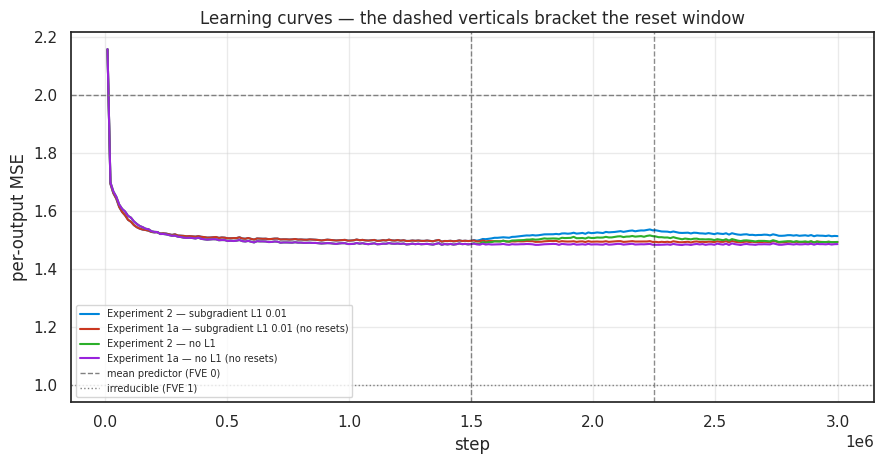

In [10]:
plt.figure(figsize=(9, 4.8))
ax = plt.gca()
palette = get_color_palette(n=2 * len(CONFIGS))

exp1_params, exp1_metrics, _ = _csv_paths('multi-geoff-experiment-1')
exp1_runs = (load_experiment_data(exp1_params, exp1_metrics)[1]
             if os.path.exists(exp1_metrics) else None)


def _pre_reset_curve(rdf):
    """Mean loss per log point over the steps before the first reset."""
    rdf = rdf.dropna(subset=['loss'])
    return rdf[rdf['step'] <= RESET_WINDOW[0]].groupby('step')['loss'].mean()


for i, (key, spec) in enumerate(SPECS.items()):
    plot_learning_curve(runs, spec.name, label=f'Experiment 2 — {spec.label}',
                        color=palette[2 * i], ax=ax, n_seeds=N_MAIN_SEEDS, show_ci=False)
    if exp1_runs is None:
        continue
    exp1_sweep = CONFIGS[key]['exp1_sweep']
    plot_learning_curve(exp1_runs, exp1_sweep, label=f'Experiment 1a — {spec.label} (no resets)',
                        color=palette[2 * i + 1], ax=ax, n_seeds=30, show_ci=False)

    a, b = _pre_reset_curve(runs[spec.name]), _pre_reset_curve(exp1_runs[exp1_sweep])
    overlap = a.index.intersection(b.index)
    if len(overlap):
        rel = np.abs(a[overlap] - b[overlap]) / b[overlap]
        print(f'{spec.label:>22s}: pre-reset agreement with {exp1_sweep} over {len(overlap)} '
              f'shared log points — max {rel.max():.2%}, mean {rel.mean():.2%}')
    else:
        print(f'{spec.label:>22s}: no shared log points with Experiment 1 (different binning).')

if exp1_runs is None:
    print('Experiment 1 CSVs not found; run experiment_1.ipynb to enable this comparison.')

ax.axvline(RESET_WINDOW[0], c='k', lw=1, ls='--', alpha=0.5)
ax.axvline(RESET_WINDOW[1], c='k', lw=1, ls='--', alpha=0.5)
ax.axhline(BASELINE_MSE, ls='--', c='gray', lw=1, label='mean predictor (FVE 0)')
ax.axhline(IRREDUCIBLE_MSE, ls=':', c='gray', lw=1, label='irreducible (FVE 1)')
ax.set_ylabel('per-output MSE')
ax.set_title('Learning curves — the dashed verticals bracket the reset window')
ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

## Visual check 1 — the stage raster

A subsample of connections on the y-axis, grouped into useful (top block) and useless (bottom
block) and sorted by reset step; time on the x-axis; colour is the stage. The black staircase is
the reset schedule — everything to its left is the connection's pre-reset life, everything to its
right is the freshly-generated regime the rule is actually meant to govern.

What the plan predicts: to the right of the staircase, useful connections should climb
nascent → growth → mature, and useless ones should mostly stay nascent.

**Red is not a stage.** It marks connections that Experiment 3's *prune* rule would already have
removed — the weight crossed zero on some step while `h` was jitter-sized
($h_i^2 < \alpha_i v / 4$, the same threshold the maturity test uses, read on `w` instead of `h`).
Nothing is actually pruned here; the rule is evaluated alongside training and the first step it
would have fired is recorded, so the two halves of Experiment 3's connectivity rule — what it
would remove and what it would let a new connection grow from — can be read off the same run.
Red overrides the stage colour, because past that point the connection would not exist.

Two rasters are drawn: stages alone, then the same thing with the prune overlay. They are
separated because the overlay turns out to cover almost everything, which is itself the finding
but would otherwise leave no stage information visible.

**Read the red carefully.** It means "the rule has fired at least once since this connection's
reset", and it is sticky, so it says nothing about how *often* the rule fires afterwards. Both L1
configurations look equally and permanently red even though their firing rates differ by two orders
of magnitude. The rate and the newborn survival curve below are what separate them.

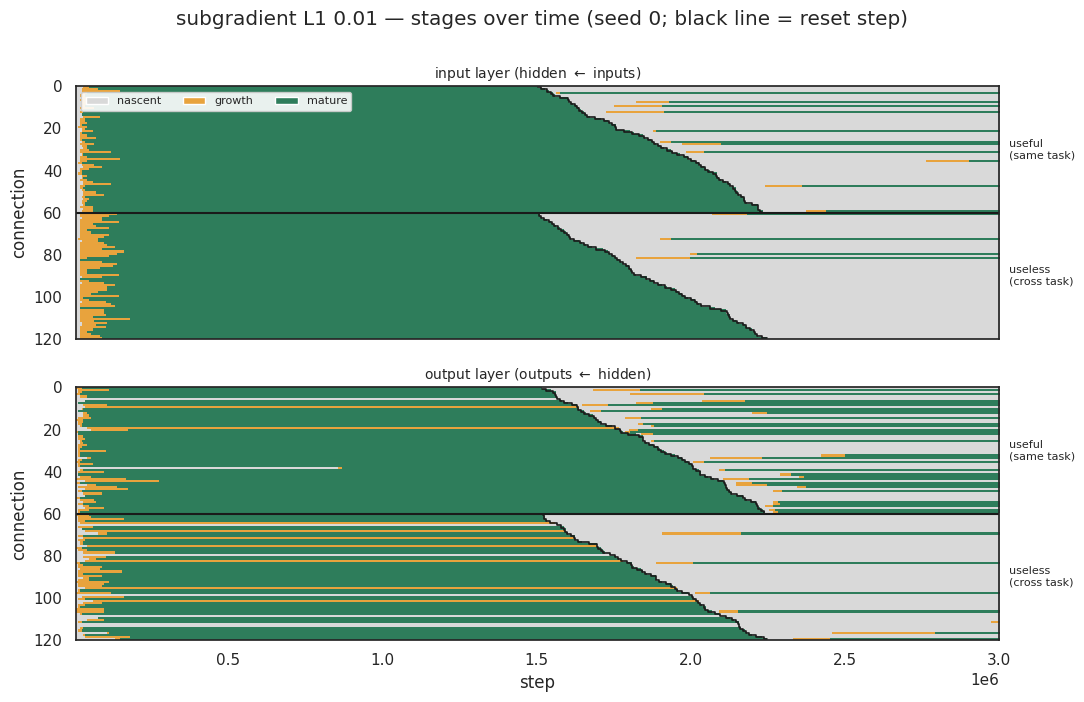

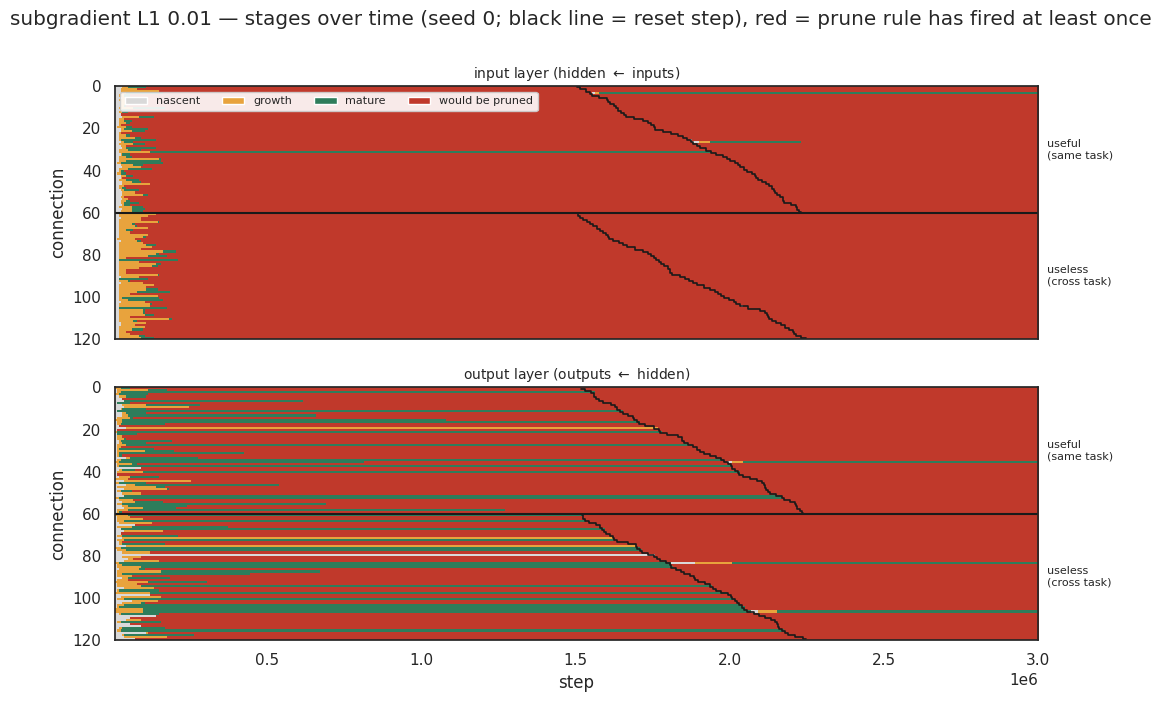

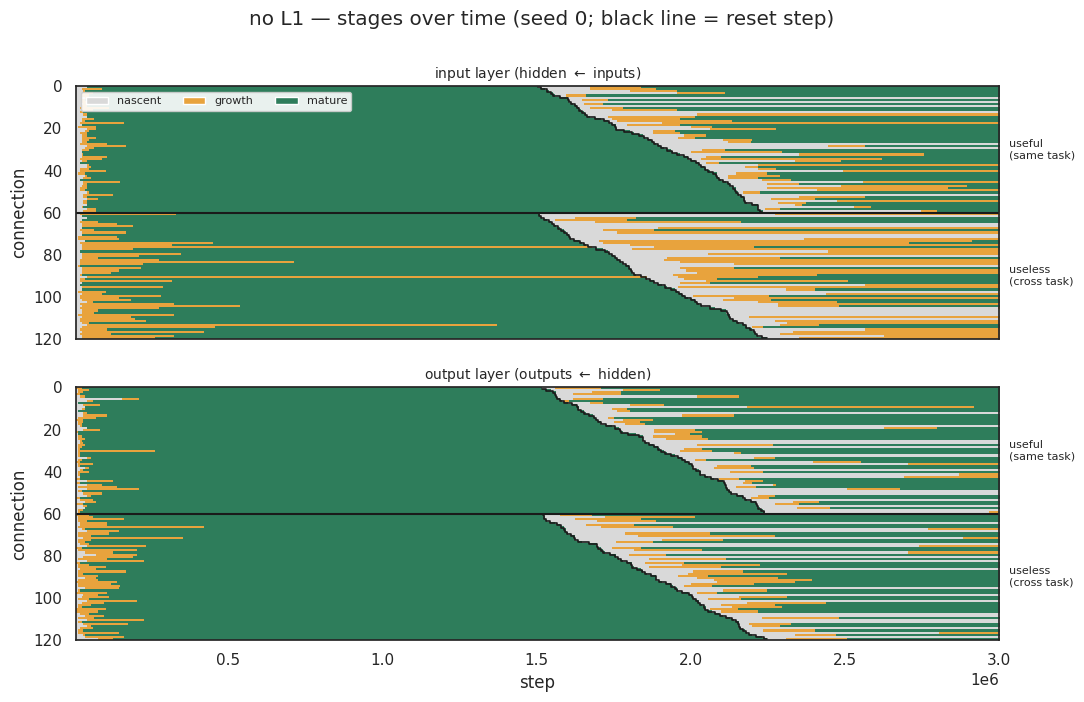

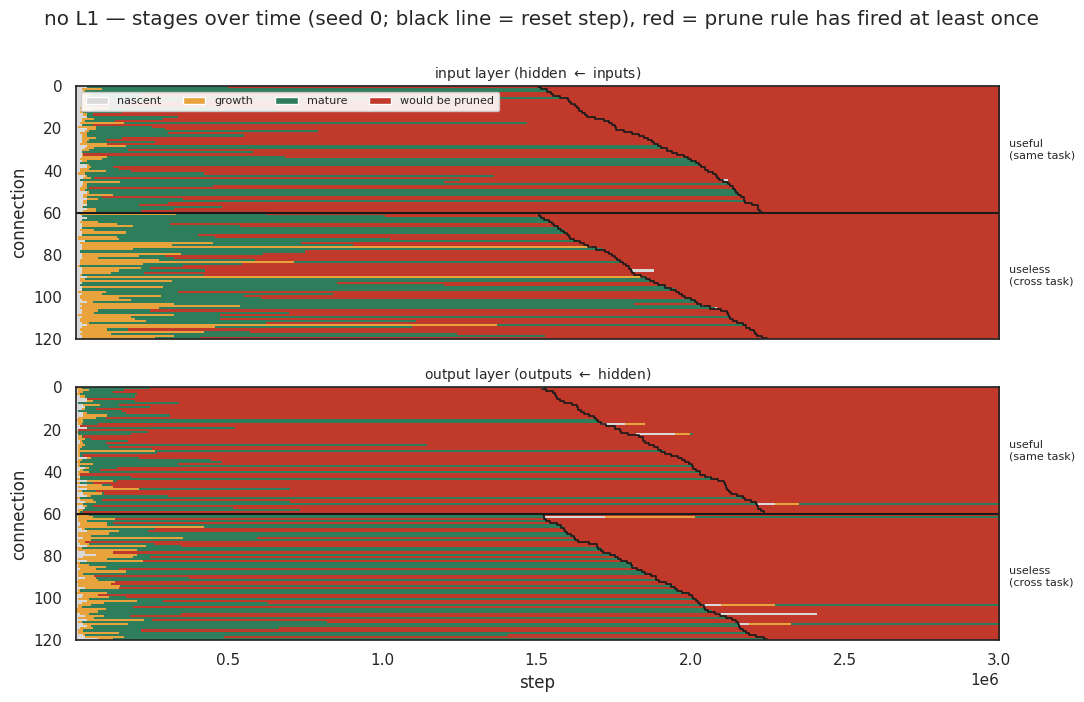

In [11]:
def plot_stage_raster(traces, log_steps, title, seed=0, show_pruned=True, axes=None):
    """One panel per layer; useful connections above useless, each block sorted by reset step.

    With `show_pruned`, red overrides the stage colour from the first step Experiment 3's prune
    rule would have fired, because past that point the connection would not exist.
    """
    stages = np.asarray(traces['stage_tr'], dtype=int)[seed]      # (snapshots, layer, group, n)
    colors = STAGE_COLORS
    if show_pruned:
        stages = np.where(np.asarray(traces['pruned_tr'], dtype=bool)[seed], PRUNED, stages)
        colors = colors + (PRUNED_COLOR,)
    if axes is None:
        _, axes = plt.subplots(len(LAYERS), 1, figsize=(11, 7), sharex=True)
    axes = np.atleast_1d(axes)
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(np.arange(cmap.N + 1) - 0.5, cmap.N)

    for li, (ax, layer) in enumerate(zip(axes, LAYERS)):
        blocks, resets, boundaries = [], [], []
        for group in GROUPS:
            order = np.argsort(TRACE_RESET_STEPS[layer][group])
            blocks.append(stages[:, li, group, :].T[order])       # (n_traces, snapshots)
            resets.append(np.asarray(TRACE_RESET_STEPS[layer][group])[order])
            boundaries.append(sum(b.shape[0] for b in blocks))

        image = np.concatenate(blocks, axis=0)
        ax.imshow(image, aspect='auto', interpolation='nearest', cmap=cmap, norm=norm,
                  extent=[log_steps[0], log_steps[-1], image.shape[0], 0])
        # One staircase per block: the two are sorted independently, so drawing them as a single
        # line would jump backwards in x at the boundary.
        for block_resets, lo in zip(resets, [0] + boundaries[:-1]):
            ax.step(block_resets, np.arange(len(block_resets)) + lo + 0.5, where='mid',
                    c='k', lw=1.2)
        ax.axhline(boundaries[0], c='k', lw=1.5)
        for name, lo, hi in zip(GROUP_NAMES, [0] + boundaries[:-1], boundaries):
            ax.text(log_steps[-1] * 1.01, (lo + hi) / 2, name.replace(' (', '\n('),
                    va='center', fontsize=8)
        ax.set_ylabel('connection')
        ax.set_title(LAYER_NAMES[li], fontsize=10)

    names = STAGE_NAMES + (('would be pruned',) if show_pruned else ())
    axes[-1].set_xlabel('step')
    handles = [plt.Rectangle((0, 0), 1, 1, fc=c) for c in colors]
    axes[0].legend(handles, names, loc='upper left', fontsize=8, ncol=len(names), framealpha=0.9)
    plt.suptitle(f'{title} — stages over time (seed {seed}; black line = reset step)'
                 + (', red = prune rule has fired at least once' if show_pruned else ''), y=1.0)
    plt.tight_layout()
    return axes


# Stages alone first, then the prune overlay. The overlay swamps the stages — which is the result,
# but it would otherwise leave nothing to read the stage rule off.
for _key, _spec in SPECS.items():
    for _show_pruned in (False, True):
        plot_stage_raster(TRACES[_key], LOG_STEPS, _spec.label, show_pruned=_show_pruned)
        plt.show()

## Visual check 2 — the thresholds themselves

For a handful of reset connections in each group: $|w|$ against its growth threshold $J_w$, and
$h$ against $\pm J_h$, with the reset and any stage transitions marked. This is the figure that
shows *why* the rule fires or does not — whether a connection failed to mature because its weight
never cleared $J_w$, or because it cleared it and then `h` never crossed zero.

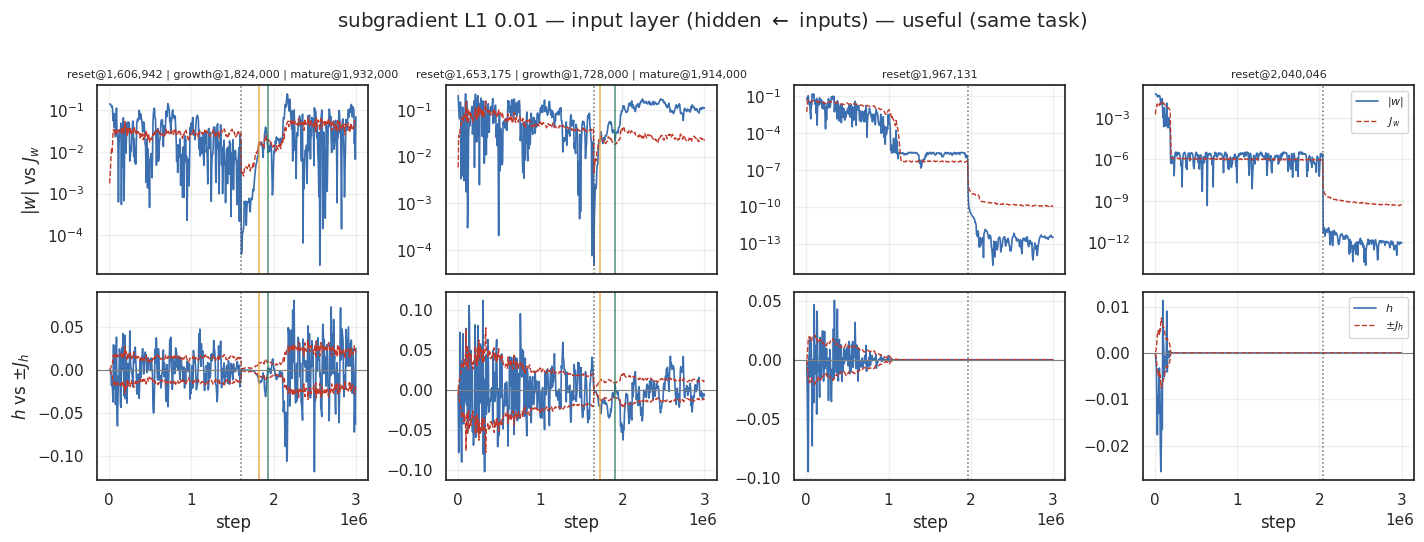

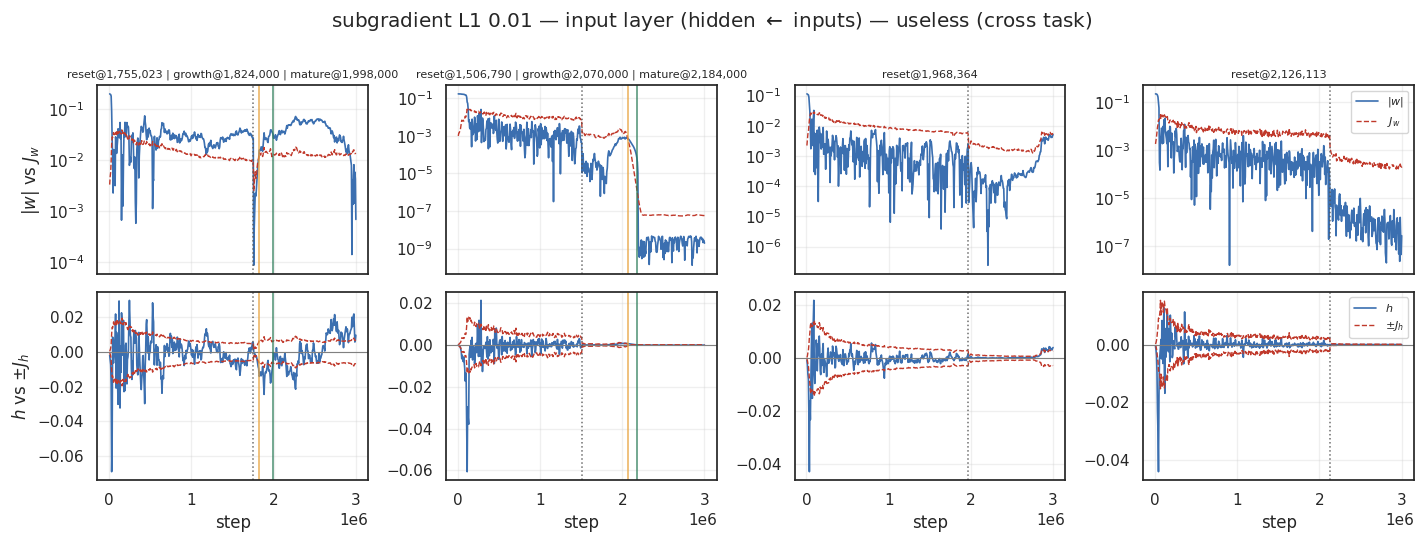

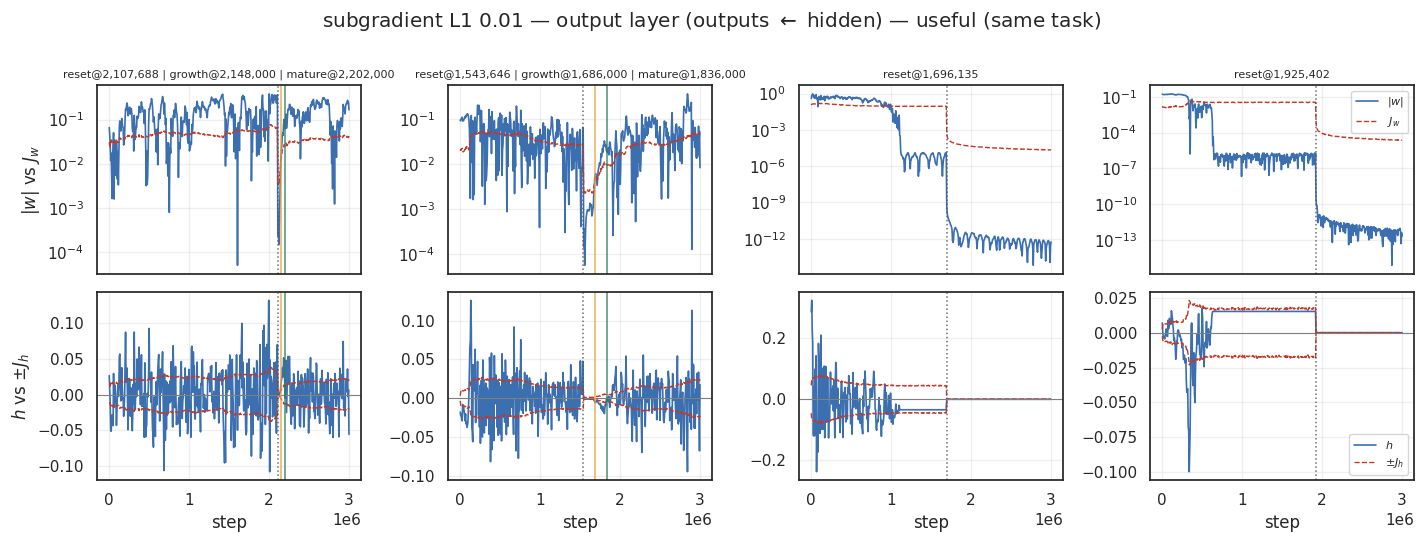

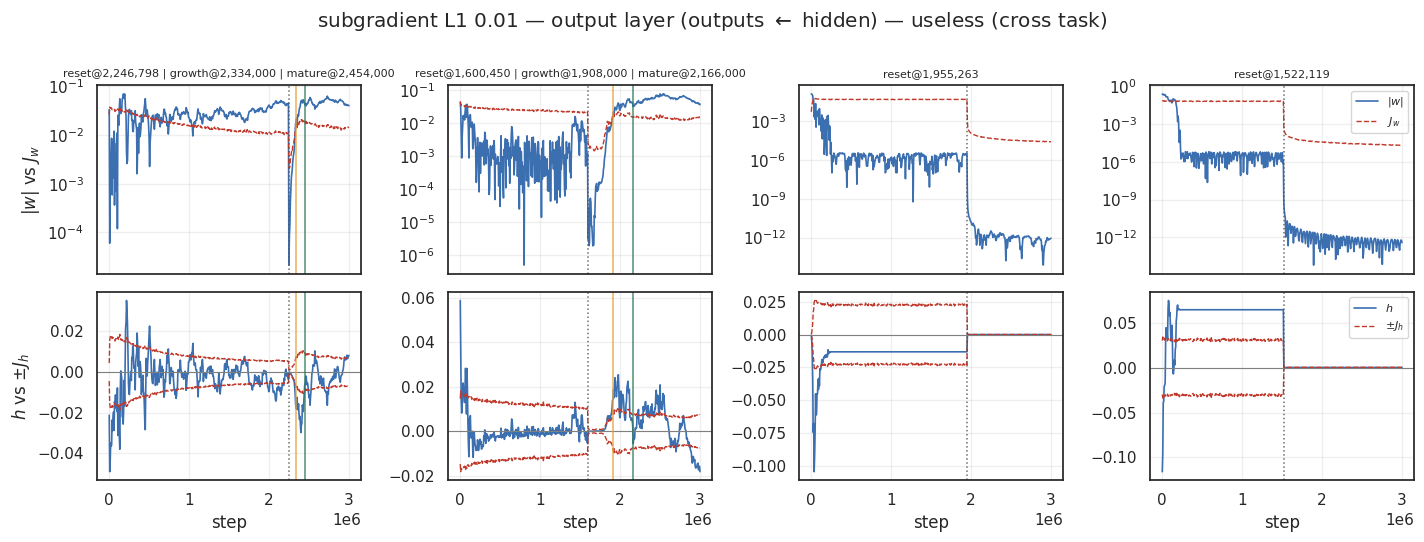

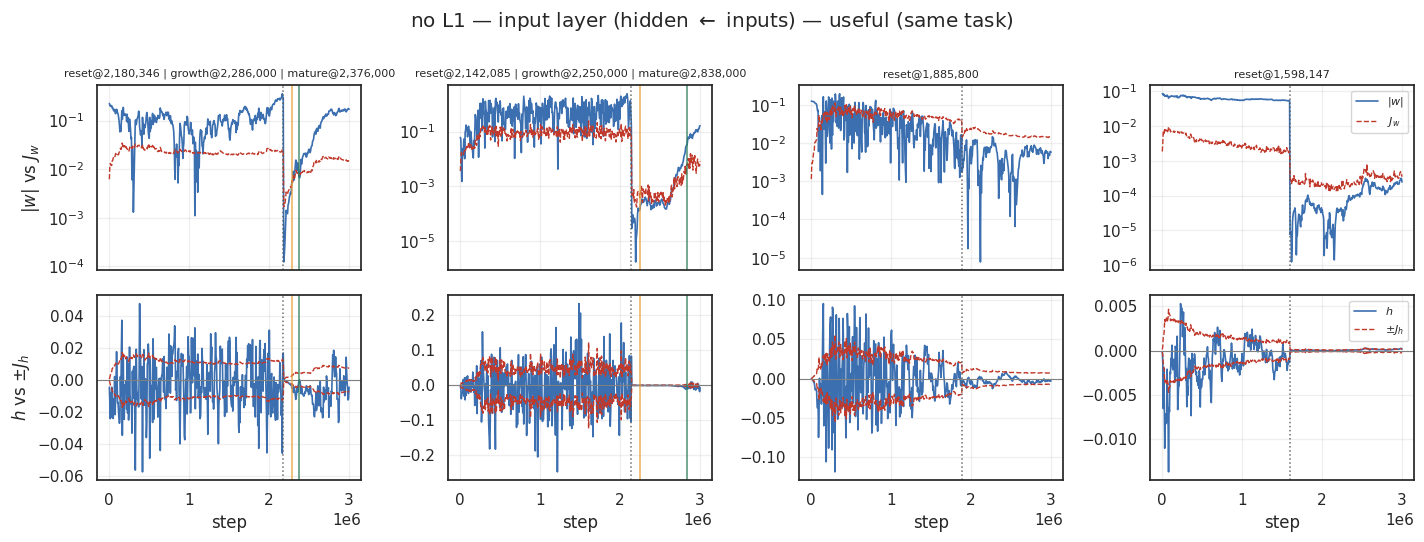

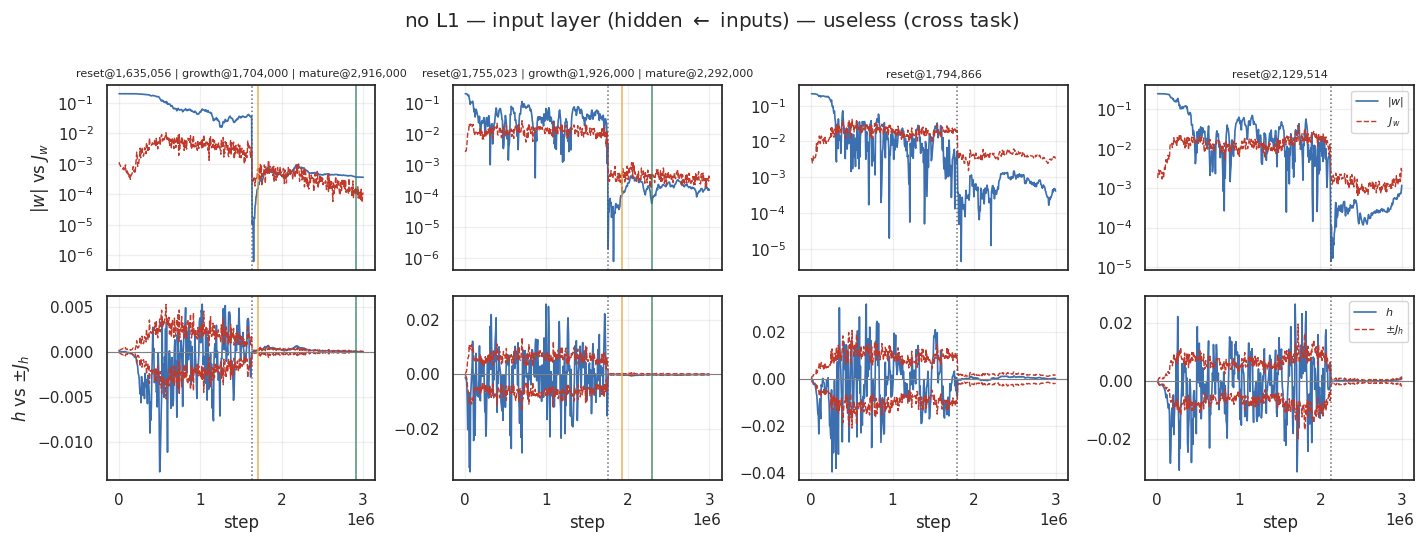

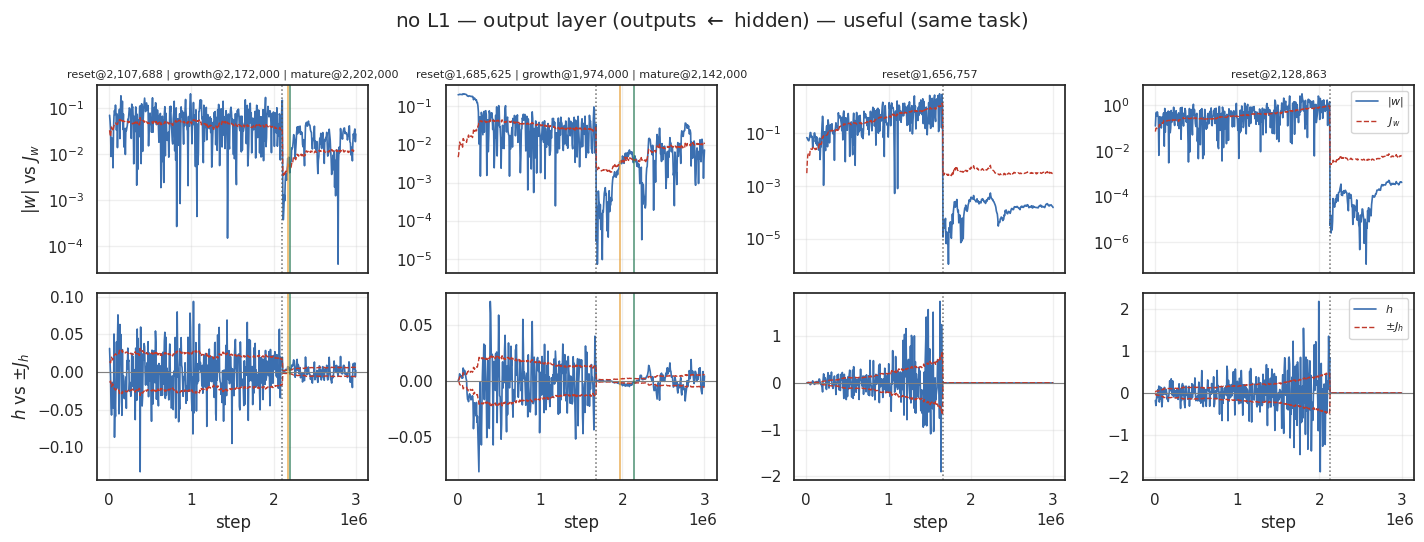

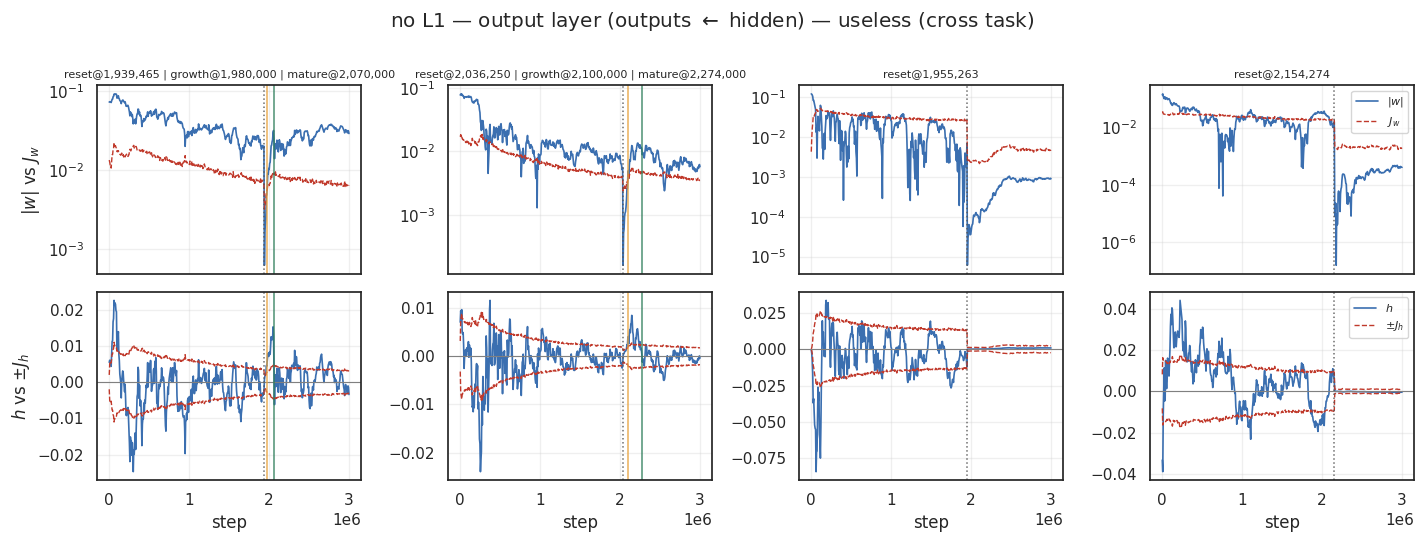

In [12]:
def plot_threshold_overlays(traces, log_steps, layer, group, title, n=4, seed=0):
    """|w| vs J_w and h vs +/- J_h for `n` reset connections, one column each."""
    li = LAYERS.index(layer)
    get = lambda key: np.asarray(traces[key])[seed, :, li, group, :]
    reset_steps = TRACE_RESET_STEPS[layer][group]
    stages = get('stage_tr').astype(int)

    # Rank by how far each connection got *after* its reset — before it, every connection has been
    # growing since step 0 and they are all mature, so ranking over the whole trace is a coin
    # flip. Show the most and the least successful half each, so the figure is neither four flat
    # lines nor a curated set of successes.
    post_reset = log_steps[None, :] > reset_steps[:, None]
    progress = np.where(post_reset, stages.T, NASCENT).max(axis=1)
    order = np.argsort(-progress)
    ranked = np.concatenate([order[:n - n // 2], order[::-1][:n // 2]])

    fig, axes = plt.subplots(2, len(ranked), figsize=(3.6 * len(ranked), 5.4), sharex=True,
                             squeeze=False)
    for col, idx in enumerate(ranked):
        reset = reset_steps[idx]
        transitions = [('reset', reset, '#555555')]
        for stage, name in ((GROWTH, 'growth'), (MATURE, 'mature')):
            after = np.where((stages[:, idx] >= stage) & (log_steps > reset))[0]
            if len(after):
                transitions.append((name, log_steps[after[0]], STAGE_COLORS[stage]))

        top, bottom = axes[0][col], axes[1][col]
        top.plot(log_steps, get('absw_tr')[:, idx], c='#3b6fb0', lw=1.2, label='$|w|$')
        top.plot(log_steps, get('jw_tr')[:, idx], c='#c0392b', lw=1.0, ls='--', label='$J_w$')
        top.set_yscale('log')

        bottom.plot(log_steps, get('h_tr')[:, idx], c='#3b6fb0', lw=1.2, label='$h$')
        bottom.plot(log_steps, get('jh_tr')[:, idx], c='#c0392b', lw=1.0, ls='--', label='$\\pm J_h$')
        bottom.plot(log_steps, -get('jh_tr')[:, idx], c='#c0392b', lw=1.0, ls='--')
        bottom.axhline(0, c='gray', lw=0.8)

        for ax in (top, bottom):
            for name, step, color in transitions:
                ax.axvline(step, c=color, lw=1.1, ls=':' if name == 'reset' else '-', alpha=0.85)
            ax.grid(True, alpha=0.3)
        top.set_title(' | '.join(f'{n_}@{int(s):,}' for n_, s, _ in transitions), fontsize=8)
        bottom.set_xlabel('step')

    axes[0][0].set_ylabel('$|w|$ vs $J_w$')
    axes[1][0].set_ylabel('$h$ vs $\\pm J_h$')
    axes[0][-1].legend(fontsize=8)
    axes[1][-1].legend(fontsize=8)
    plt.suptitle(f'{title} — {LAYER_NAMES[li]} — {GROUP_NAMES[group]}', y=1.0)
    plt.tight_layout()
    return axes


for _key, _spec in SPECS.items():
    for _layer in LAYERS:
        for _group in GROUPS:
            plot_threshold_overlays(TRACES[_key], LOG_STEPS, _layer, _group, _spec.label)
            plt.show()

## Quantitative checks

All three are computed over **reset** connections only, from the exact per-connection transition
steps recorded inside the training loop (not from the snapshots), so nothing is quantized to the
snapshot grid. Fractions are computed per seed and then averaged, with a 95% confidence interval
on the mean over seeds. Every table carries both configurations, L1 first.

In [13]:
def _reset_selection(traces, layer, group):
    """Boolean mask of the connections in `group` that the run's own schedule resets.

    Read from the cached `reset_step_*` rather than the notebook-level `RESET_STEP`, so a run made
    under a different schedule — the ablation at the end — is analysed against its own.
    """
    reset_step = np.asarray(traces[f'reset_step_{layer}'])
    return (np.asarray(labels[layer]) == group) & (reset_step != NEVER)


def _per_seed_fraction(traces, key, layer, group):
    """Per-seed fraction of the group's reset connections with a recorded transition."""
    reached = np.asarray(traces[f'final_{key}_{layer}']) != NEVER     # (seeds, out, in)
    sel = _reset_selection(traces, layer, group)
    return reached[:, sel].mean(axis=1)


def _per_seed_conditional(traces, layer, group):
    """Per-seed fraction of the group's *grown* reset connections that went on to mature.

    Separates the two gates: a value near 1 means the h-crossing test lets through everything the
    growth threshold admitted, so maturity carries no information the growth stage did not.
    """
    grew = np.asarray(traces[f'final_growth_step_{layer}']) != NEVER
    matured = np.asarray(traces[f'final_mature_step_{layer}']) != NEVER
    sel = _reset_selection(traces, layer, group)
    n_grew = grew[:, sel].sum(axis=1)
    return np.where(n_grew > 0, matured[:, sel].sum(axis=1) / np.maximum(n_grew, 1), np.nan)


def _mean_ci(values):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan
    return values.mean(), float(ci_halfwidth(values.std(), len(values)))

### (a) Do useless connections enter growth more often than chance?

The chance model. A useless connection's weight is driven by an error that is uncorrelated with
its input, so under LMS it is an Ornstein–Uhlenbeck process: the mean update is
$-\alpha \mathbb{E}[x^2] w$ and the update noise has variance $\alpha^2 \mathbb{E}[x^2] v$, giving a
stationary standard deviation $\sigma = \sqrt{\alpha v / 2} = \sqrt{2} J_h$ and a correlation time
$\tau = 1 / (\alpha \mathbb{E}[x^2])$. The growth threshold sits at $J_w = 2 J_h = \sqrt{2}\,\sigma$
(taking $c \approx 1$), so a jittering weight exceeds it on $2\Phi(-\sqrt{2}) = 15.7\%$ of steps and
crosses it roughly once per $\tau$ steps — over the ~$T$ steps a reset connection is observed for,
that predicts **essentially every** useless connection entering growth eventually.

That is the L1-free prediction. Subgradient L1 adds a restoring force of $\alpha \lambda$ toward
zero that dominates the jitter at these step-sizes, so the *observed* $\sigma$ is much smaller than
$\sqrt{2} J_h$. The table therefore reports the chance prediction twice: once from the analytic
$\sigma$, and once from the $\sigma$ measured on this run's nascent useless weights.

**Which column to read.** The observed-$\sigma$ column is the fair comparison when most useless
connections are still nascent, which is the L1 run. It is not trustworthy in the no-L1 run: three
quarters of the useless connections have already left the nascent state there, so the surviving
nascent sample is censored — it is precisely the connections whose weights stayed small — and
$\sigma_{obs}$ is biased downward accordingly (visible as $\sigma_{obs}/J_h = 0.51$ for w1, below
the analytic $\sqrt 2$). For that run the analytic column is the meaningful reference.

In [14]:
def growth_vs_chance(traces, log_steps, run_label, tail_fraction=0.25):
    """Measured growth rate of reset useless connections against the jitter model."""
    rows = []
    for li, layer in enumerate(LAYERS):
        measured, ci = _mean_ci(_per_seed_fraction(traces, 'growth_step', layer, USELESS))

        # The sub-threshold weight scale, measured on traced useless connections that are still
        # nascent over the tail of the run. Those are exactly the connections the jitter model
        # describes: reset, never grown, weight doing nothing but jitter. Only the `N_TRACE_SEEDS`
        # cached seeds contribute here, since the per-connection weights are what it needs; the
        # measured rate it is compared against uses all of them.
        tail = slice(int((1 - tail_fraction) * len(log_steps)), None)
        w = np.asarray(traces['w_tr'])[:, tail, li, USELESS, :]
        j_h = np.asarray(traces['jh_tr'])[:, tail, li, USELESS, :]
        j_w = np.asarray(traces['jw_tr'])[:, tail, li, USELESS, :]
        nascent = np.asarray(traces['stage_tr'])[:, tail, li, USELESS, :] == NASCENT
        if nascent.sum() < 2:
            rows.append({'run': run_label, 'layer': layer, 'measured growth rate': measured,
                         'CI': ci,
                         'note': 'no nascent useless traces left to fit the jitter model'})
            continue

        sigma_obs = float(np.std(w[nascent]))
        j_h_mean, j_w_mean = float(np.mean(j_h[nascent])), float(np.mean(j_w[nascent]))

        # Correlation time tau = 1 / (alpha * E[x^2]), per connection, from the final step-sizes
        # and the run-mean squared source values.
        sel = _reset_selection(traces, layer, USELESS)
        alpha = np.asarray(traces[f'final_alpha_{layer}'])[:, sel].mean()
        mean_x2 = np.asarray(traces[f'mean_x2_{layer}']).mean(axis=0)
        # Broadcast the per-source-unit mean over the selected connections.
        x2 = np.broadcast_to(mean_x2[None, :], np.asarray(labels[layer]).shape)[sel].mean()
        tau = 1.0 / (alpha * x2)
        horizon = float(np.mean(
            NUM_STEPS - np.asarray(traces[f'reset_step_{layer}'])[sel]))

        def p_ever(sigma):
            p_step = 2 * stats.norm.cdf(-j_w_mean / max(sigma, 1e-30))
            return 1.0 - (1.0 - p_step) ** (horizon / tau), p_step

        chance_obs, p_obs = p_ever(sigma_obs)
        chance_analytic, p_analytic = p_ever(np.sqrt(2) * j_h_mean)

        rows.append({
            'run': run_label, 'layer': layer,
            'measured growth rate': measured, 'CI': ci,
            'sigma_obs / J_h': sigma_obs / j_h_mean,
            'P(|w| > J_w) per step': p_obs,
            'tau (steps)': tau,
            'crossings expected': horizon / tau,
            'chance, observed sigma': chance_obs,
            'chance, jitter model': chance_analytic,
        })
    return pd.DataFrame(rows)


print('Reset USELESS connections — measured vs. chance under the jitter model\n')
print(pd.concat([growth_vs_chance(TRACES[k], LOG_STEPS, s.label) for k, s in SPECS.items()])
      .to_string(index=False, float_format=lambda v: f'{v:.4g}'))

Reset USELESS connections — measured vs. chance under the jitter model

                run layer  measured growth rate      CI  sigma_obs / J_h  P(|w| > J_w) per step  tau (steps)  crossings expected  chance, observed sigma  chance, jitter model
subgradient L1 0.01    w1               0.09922  0.0184            1.459                 0.1704    2.003e+06              0.5709                  0.1011               0.09309
subgradient L1 0.01    w2                0.2792 0.03645            2.272                 0.3787    6.748e+05               1.661                  0.5464                0.2474
              no L1    w1                0.7528 0.03061           0.5144              0.0001011    6.805e+04               16.81                0.001698                0.9437
              no L1    w2                0.7029 0.03279            4.566                 0.6614        104.1           1.077e+04                       1                     1


### (b) The maturity split

The number the rule lives or dies by: near 0 of the useless connections should mature, and near all
of the useful ones should. Growth rates are shown alongside, so a failure can be attributed to the
right gate.

                run layer   group  n reset (per seed)  reached growth  reached growth CI  reached mature  reached mature CI  mature | growth  ever pruned  fires / conn / step
subgradient L1 0.01    w1  useful                 532          0.2812            0.01554          0.2658            0.01459           0.9457        0.988               0.1416
subgradient L1 0.01    w1 useless                 171         0.09922             0.0184         0.09025            0.01666           0.9108       0.9996               0.1543
subgradient L1 0.01    w2  useful                 253          0.5265            0.01867          0.5235            0.01907            0.994       0.9793               0.2094
subgradient L1 0.01    w2 useless                  80          0.2792            0.03645          0.2487            0.03564            0.886       0.9908               0.2853
              no L1    w1  useful                 532          0.7586            0.02273          0.6724            0.02113  

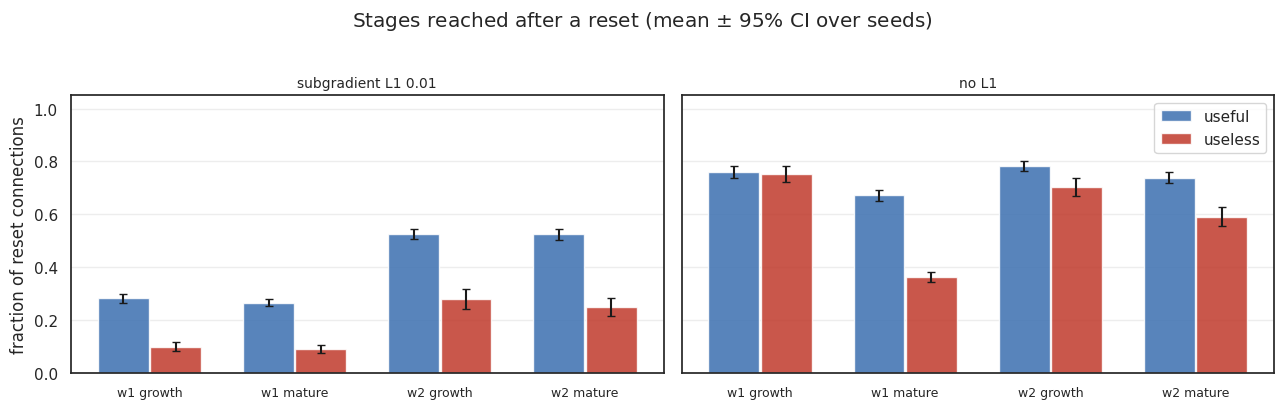

In [15]:
def maturity_table(traces, run_label):
    rows = []
    for layer in LAYERS:
        for group, name in zip(GROUPS, ('useful', 'useless')):
            row = {'run': run_label, 'layer': layer, 'group': name,
                   'n reset (per seed)': int(_reset_selection(traces, layer, group).sum())}
            for key, label in (('growth_step', 'growth'), ('mature_step', 'mature')):
                mean, ci = _mean_ci(_per_seed_fraction(traces, key, layer, group))
                row[f'reached {label}'] = mean
                row[f'reached {label} CI'] = ci
            row['mature | growth'], _ = _mean_ci(_per_seed_conditional(traces, layer, group))
            # Two very different statistics, deliberately side by side: whether the prune rule
            # ever fired on a connection in the ~750k steps after its reset, and how often it
            # fires per connection per step. The first is near 1 for any rule that fires at all;
            # only the second is comparable across problems (see the section after next).
            row['ever pruned'], _ = _mean_ci(
                _per_seed_fraction(traces, 'prune_step', layer, group))
            sel = _reset_selection(traces, layer, group)
            row['fires / conn / step'] = float(
                np.asarray(traces[f'final_prune_count_{layer}'])[:, sel].mean() / NUM_STEPS)
            rows.append(row)
    return pd.DataFrame(rows)


MATURITY = {key: maturity_table(TRACES[key], spec.label) for key, spec in SPECS.items()}
print(pd.concat(MATURITY.values()).to_string(index=False, float_format=lambda v: f'{v:.4g}'))

fig, axes = plt.subplots(1, len(SPECS), figsize=(6.5 * len(SPECS), 4), sharey=True)
width, offsets = 0.35, {'useful': -0.18, 'useless': 0.18}
colors = {'useful': '#3b6fb0', 'useless': '#c0392b'}
positions = {f'{l} {s}': i for i, (l, s) in enumerate(
    [(l, s) for l in LAYERS for s in ('growth', 'mature')])}
for ax, (key, spec) in zip(np.atleast_1d(axes), SPECS.items()):
    for group in ('useful', 'useless'):
        sub = MATURITY[key][MATURITY[key]['group'] == group]
        xs, ys, es = [], [], []
        for _, r in sub.iterrows():
            for stage in ('growth', 'mature'):
                xs.append(positions[f"{r['layer']} {stage}"] + offsets[group])
                ys.append(r[f'reached {stage}'])
                es.append(r[f'reached {stage} CI'])
        ax.bar(xs, ys, width, yerr=es, capsize=3, color=colors[group], label=group, alpha=0.85)
    ax.set_xticks(list(positions.values()))
    ax.set_xticklabels(list(positions), fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.grid(True, axis='y', alpha=0.35)
    ax.set_title(spec.label, fontsize=10)
np.atleast_1d(axes)[0].set_ylabel('fraction of reset connections')
np.atleast_1d(axes)[-1].legend()
plt.suptitle('Stages reached after a reset (mean $\\pm$ 95% CI over seeds)', y=1.02)
plt.tight_layout()
plt.show()

### (c) How long does a useful connection take to mature?

Time from reset to maturity, pooled over seeds. The never-matured fraction is stated rather than
dropped — a short median over the 5% that made it would be a misleading summary.

   subgradient L1 0.01  w1  useful: matured  26.6%;  median   153,863 steps  (IQR 72,384 - 362,044)
   subgradient L1 0.01  w2  useful: matured  52.3%;  median   117,019 steps  (IQR 66,257 - 242,617)
                 no L1  w1  useful: matured  67.2%;  median   226,142 steps  (IQR 127,776 - 400,434)
                 no L1  w2  useful: matured  73.9%;  median   193,888 steps  (IQR 120,146 - 332,354)


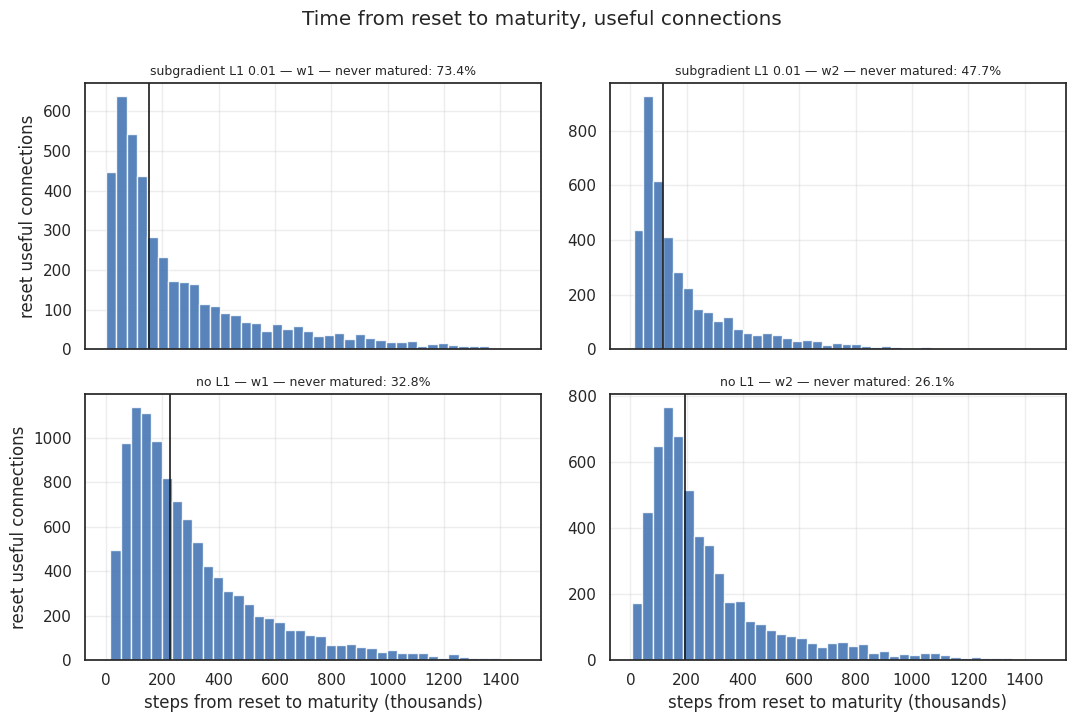


Steps from reset to the first firing of the prune rule:
     subgradient L1 0.01  w1  useful : fired for  98.8%;  median          3  (IQR 2 - 9)
     subgradient L1 0.01  w1  useless: fired for 100.0%;  median          5  (IQR 2 - 9)
     subgradient L1 0.01  w2  useful : fired for  97.9%;  median          2  (IQR 2 - 6)
     subgradient L1 0.01  w2  useless: fired for  99.1%;  median          2  (IQR 2 - 4)
                   no L1  w1  useful : fired for  98.2%;  median          5  (IQR 2 - 20)
                   no L1  w1  useless: fired for  99.4%;  median          5  (IQR 3 - 20)
                   no L1  w2  useful : fired for  96.3%;  median          5  (IQR 2 - 18)
                   no L1  w2  useless: fired for  96.6%;  median          5  (IQR 3 - 19)


In [16]:
def time_to(traces, layer, group=USEFUL, key='mature_step'):
    """Per-connection delay from reset to `key`, in steps, and the fraction it never reached."""
    reached_at = np.asarray(traces[f'final_{key}_{layer}'])           # (seeds, out, in)
    sel = _reset_selection(traces, layer, group)
    reset = np.broadcast_to(
        np.asarray(traces[f'reset_step_{layer}'])[None], reached_at.shape)[:, sel]
    reached_at = reached_at[:, sel]
    reached = reached_at != NEVER
    return (reached_at[reached] - reset[reached]), 1.0 - reached.mean()


fig, axes = plt.subplots(len(SPECS), len(LAYERS), figsize=(11, 3.6 * len(SPECS)),
                         sharex=True, squeeze=False)
for row, (key, spec) in zip(axes, SPECS.items()):
    for ax, layer in zip(row, LAYERS):
        delays, never = time_to(TRACES[key], layer)
        if len(delays):
            ax.hist(delays / 1000, bins=40, color='#3b6fb0', alpha=0.85)
            q1, med, q3 = np.percentile(delays, [25, 50, 75])
            ax.axvline(med / 1000, c='k', lw=1.2)
            print(f'{spec.label:>22s}  {layer}  useful: matured {1 - never:6.1%};  '
                  f'median {med:>9,.0f} steps  (IQR {q1:,.0f} - {q3:,.0f})')
        else:
            print(f'{spec.label:>22s}  {layer}  useful: no reset connection ever matured')
        ax.set_title(f'{spec.label} — {layer} — never matured: {never:.1%}', fontsize=9)
        ax.grid(True, alpha=0.35)
    row[0].set_ylabel('reset useful connections')
for ax in axes[-1]:
    ax.set_xlabel('steps from reset to maturity (thousands)')
plt.suptitle('Time from reset to maturity, useful connections', y=1.0)
plt.tight_layout()
plt.show()

# How long a freshly reset connection survives the prune rule. This is the number that decides
# whether Experiment 3's generate-then-prune loop can work at all: a newly created connection
# starts at w = 0 with h = 0, which is the deepest possible inside the "h is small" half of the
# prune test, so it has to grow a weight before it flips sign or it is removed again immediately.
print('\nSteps from reset to the first firing of the prune rule:')
for key, spec in SPECS.items():
    for layer in LAYERS:
        for group, name in zip(GROUPS, ('useful ', 'useless')):
            delays, never = time_to(TRACES[key], layer, group, key='prune_step')
            if len(delays):
                q1, med, q3 = np.percentile(delays, [25, 50, 75])
                print(f'  {spec.label:>22s}  {layer}  {name}: fired for {1 - never:6.1%};  '
                      f'median {med:>10,.0f}  (IQR {q1:,.0f} - {q3:,.0f})')
            else:
                print(f'  {spec.label:>22s}  {layer}  {name}: never fired')

## What these runs say

The bookkeeping is honest: over the 125 log points before the first reset, both runs reproduce
their Experiment 1 counterparts (`exp1a_l1_variant_b`, `exp1a_variant_b`) to **0.00%** relative
difference, so the stages are genuinely read-only with respect to training and everything below is
about the rule rather than about a perturbed learner.

Fractions of **reset** connections, per layer:

| | L1 w1 | L1 w2 | no-L1 w1 | no-L1 w2 |
|---|---|---|---|---|
| useful reached mature | 26.6% | 52.4% | 67.2% | 73.9% |
| useless reached mature | 9.0% | 24.9% | 36.2% | 59.0% |
| useful / useless ratio | 2.9x | 2.1x | 1.9x | 1.3x |
| P(mature \| growth), useful | 0.95 | 0.99 | 0.89 | 0.94 |
| P(mature \| growth), useless | 0.91 | 0.89 | **0.49** | 0.84 |
| ever pruned (over ~750k steps) | 98.8% | 97.9% | 98.2% | 96.3% |
| prune rule fires / conn / step | **0.069** | **0.178** | 0.00046 | 0.00065 |

### What L1 is responsible for

**The maturity test is vacuous under subgradient L1, and only under it.** With L1, a connection
that reaches growth matures with probability 0.89–0.99 whether it is useful or useless — the
mechanism being the one Experiment 1 documented, that a weight in the L1 limit cycle flips sign on
~99% of steps and drags `h` with it, so the zero-crossing fires within a step or two of the growth
transition. Remove L1 and the test starts carrying information: useless input-layer connections
mature after growth only 49% of the time against 89% for useful ones. So the *design intent* of
the h-crossing test is sound; subgradient L1 destroys it.

**L1 also suppresses useful connections.** Useful maturity rises from 26.6% to 67.2% (w1) and
52.4% to 73.9% (w2) once the penalty is removed, because $J_w$ is set by $\alpha$ and $v$ rather
than by the weight scale, so shrinking every weight makes the growth gate harder to clear without
making any connection less useful.

### What L1 is not responsible for

**And L1 multiplies the prune rule's firing rate by two to three orders of magnitude.** With it, the
rule fires once every 5–15 steps *per connection*; without it, once every 1,500–2,200 steps. Both
score ~98% on "ever pruned", which is why that statistic is worth so little. The mechanism is again
the limit cycle: the prune test's first half asks whether the weight crossed zero, and a weight
cycling around zero crosses it on ~99% of steps. Note this is about *established* connections —
newborn mortality is the same with or without L1, and the same as in the linear setting. The
comparison section below separates the two.

**The growth gate leaks at roughly the jitter rate in both runs.** With L1 the measured useless
growth rate is 9.9% (w1) against 10.1% predicted from the observed weight scale. Without L1 it is
75.3% against an analytic jitter prediction of 94% — slightly tighter than pure jitter, but the
same phenomenon at a different scale. In neither case is the threshold selecting on usefulness;
it is admitting whatever the weight's own noise floor lets through.

**And no configuration gets useless maturity low enough.** Removing L1 improves useful recall but
raises useless maturity from 9%/25% to 36%/59%, so the *ratio* gets worse, not better. There is no
setting of the L1 coefficient at which this rule is a good gate.

### What this means for Experiment 3

**The maturity gate is not usable for generation.** A hidden unit matures as soon as its *first*
outgoing connection does, and hidden units here have roughly ten outgoing connections at a 25%
(L1) to 59% (no-L1) per-connection useless maturity rate — so essentially every unit would be
"mature" almost immediately, on jitter alone. The 120k–230k-step maturation delay is also long
compared with how often Experiment 3 regenerates connections, so early in training the gate would
be selecting on age rather than on quality. Switching L1 off does not rescue it: useful recall
improves but useless maturity rises further, so the ratio gets worse.

**The prune rule is workable — but not with subgradient L1.** Without L1 its churn rate
(0.0005 firings per connection per step) sits just inside the linear regime this rule was validated
in (0.00085), so 3b should be no worse off than the generate-and-test loop that worked. With
subgradient L1 it fires every 5–15 steps per connection, which would turn the entire connection
budget over roughly every ten steps — that is not a viable 3b.

**Variant 2 needs the newborn exemption either way.** A newborn's median lifetime is 2–5 steps in
every configuration, including the linear one, and only 3–6% of newborns survive even 1,000 steps,
against a median time-to-maturity of 120k–230k steps. Generate-and-test tolerates that — the linear
algorithm has the same survival curve and works — but *maturity-gated* generation does not: a new
connection essentially never lives long enough to mature, so maturity can only accrue to connections
that already exist and Variant 2 has nothing to bootstrap from.

### What to change first

Per the plan, this notebook diagnoses and stops; the revisions below are recorded, not run. The
first is what makes Variant 2 possible at all.

* **Exempt newborns from pruning.** The prune test fires on `h` being *small*, and `h` is smallest
  exactly when a connection is new. Requiring a connection to have reached the growth stage before
  it becomes prunable (or exempting it below some age) costs one extra term, removes the newborn
  churn that this setting and the linear one both pay, and is what lets a new connection live long
  enough to mature.
* **Set `connection_stages.W_JITTER_FACTOR` from a target false-positive rate.** The measured
  $\sigma / J_h \approx 1.46$ under L1 makes $J_w = 2 J_h$ a $\sqrt{2}\sigma$ threshold, which a
  jittering weight clears routinely; check (a) already reports everything needed to calibrate a
  factor that does not. This is the fix for the growth gate under either L1 setting.
* **Keep the h-crossing test, but not with subgradient L1.** The no-L1 run shows the test does
  discriminate (0.49 vs 0.89 on w1) once the limit cycle is gone. If Experiment 3 keeps subgradient
  L1, the test should be strengthened — requiring the crossing to happen while `|h|` is *above*
  $J_h$, which this run already records, is the smallest change that restores the intent. The
  proximal L1 form, which Experiment 1 found has neither the limit cycle nor frozen step-sizes,
  is the other option and would keep the sparsity benefit.

## Is the prune rule really churning more than in the linear setting?

The same rule was validated in the linear feature-sifting setting
(`phd/sandbox/feature_sifting/exploration/feature_sifting_stepsize_protection.ipynb`, section 5),
where it looked well behaved. Two things to check: whether the mechanism differs, and whether the
statistics being compared are even the same. The answer turns out to be that the headline figure was
the wrong statistic — and that once a comparable one is used, the excess churn is entirely
subgradient L1's doing.

**The mechanism, first.** A newborn starts at exactly `w = 0, h = 0`. Both then accumulate the
same increment `alpha * g` — `h`'s decay factor `(1 - alpha x^2)` is negligible early — so after
`n` steps both sit at scale `alpha * sqrt(n v E[x^2])`. The connection is only safe once `|h|`
clears `J_h = sqrt(alpha v) / 2`, i.e. after

$$n_{escape} \approx \frac{1}{4\,\alpha\,\mathbb{E}[x^2]}$$

steps, while its weight — a random walk restarted at zero — crosses zero on a large fraction of
those first steps. Note `v` cancels: the ratio `|h| / J_h = 2\sqrt{\alpha n E[x^2]}` does not
depend on the residual power at all, so *how noisy the problem is cannot matter*, only
`alpha * E[x^2]` can. That is the first thing to check.

**And the measurement.** "Ever pruned" above is exactly that — did the rule fire at any point in
the ~750k steps after a reset. A rule that fires on a connection once per thousand steps still
scores ~100% on it. The linear notebook's diagnostic is a *rate*, prunes per step, which is a
different number entirely. Comparing the two directly is the second thing to check.

### The linear rule, measured the same way

Their section-5 learner and task, re-run here so both settings are measured with the same
statistics: the per-feature per-step firing rate, the median lifetime of a newly generated
feature, and the share of all prunes that land on features less than ten steps old.

In [17]:
from phd.jax_core.tasks.feature_sifting import FeatureSiftingTask

LINEAR_N_TARGET, LINEAR_N_LEARNER = 10, 20
LINEAR_STEPS = 50_000 if not SMOKE_TEST else 5_000
LINEAR_SEEDS = 10 if not SMOKE_TEST else 2
# The best configuration the linear notebook's sweep selected.
LINEAR_INIT_LR, LINEAR_META_LR = 0.0625, 0.015625


class LinearSignFlipPrune(eqx.Module):
    """`AutostepSignFlipProtect` from the linear notebook, plus per-slot birth tracking.

    Verbatim in its update and prune rule; the only additions are the birth step of each slot and
    the two condition masks, so the same statistics can be computed as for the network.
    """
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    w: jnp.ndarray
    opt_state: optax.OptState
    v: jnp.ndarray
    prune_mask: jnp.ndarray
    birth: jnp.ndarray
    t: jnp.ndarray

    @classmethod
    def init(cls, init_lr, meta_lr):
        optimizer = optax_idbd(init_lr=init_lr, meta_lr=meta_lr, autostep=True)
        w = jnp.zeros((1, LINEAR_N_LEARNER))
        return cls(optimizer=optimizer, w=w, opt_state=optimizer.init(w), v=jnp.asarray(0.0),
                   prune_mask=jnp.zeros(LINEAR_N_LEARNER, dtype=bool),
                   birth=jnp.zeros(LINEAR_N_LEARNER, jnp.int32), t=jnp.int32(0))

    def step(self, x, y):
        y_hat = jnp.sum(self.w * x[None, :])
        error = y_hat - y
        loss, loss_grads = error ** 2, 2.0 * error * x[None, :]

        w_prev = self.w
        updates, opt_state = self.optimizer.update(
            (loss_grads, x[None, :]), self.opt_state, self.w)
        w_new = optax.apply_updates(self.w, updates)
        w_flip = (w_prev * w_new < 0.0)[0]

        step_size = jnp.exp(opt_state.beta)[0]
        v = self.v + (jnp.sum(step_size * x ** 2) / TRACE_K) * (loss - self.v)
        h_small = opt_state.h[0] ** 2 < step_size * v / 2.0
        prune_mask = w_flip & h_small

        lifetime = jnp.where(prune_mask, self.t - self.birth, -1)
        w_new = jnp.where(prune_mask[None, :], 0.0, w_new)
        opt_state = IDBDState(
            init_beta=opt_state.init_beta,
            beta=jnp.where(prune_mask[None, :], opt_state.init_beta, opt_state.beta),
            h=jnp.where(prune_mask[None, :], 0.0, opt_state.h),
            v=jnp.where(prune_mask[None, :], 0.0, opt_state.v))

        return tree_replace(self, w=w_new, opt_state=opt_state, v=v, prune_mask=prune_mask,
                            birth=jnp.where(prune_mask, self.t, self.birth), t=self.t + 1), \
            (loss, lifetime, w_flip, h_small)


def run_linear(init_lr=LINEAR_INIT_LR, meta_lr=LINEAR_META_LR, target_noise_std=0.0,
               n_steps=LINEAR_STEPS, n_seeds=LINEAR_SEEDS):
    def one_seed(seed_key):
        task = FeatureSiftingTask(LINEAR_N_TARGET, LINEAR_N_LEARNER, target_noise_std,
                                  key=seed_key)
        state = LinearSignFlipPrune.init(init_lr, meta_lr)

        def scan_step(carry, _):
            task, state = carry
            task, (x, y) = task.step(state.prune_mask)
            state, out = state.step(x, jnp.squeeze(y))
            return (task, state), out

        return jax.lax.scan(scan_step, (task, state), length=n_steps)[1]

    loss, lifetime, w_flip, h_small = jax.jit(jax.vmap(one_seed))(
        jax.random.split(jax.random.PRNGKey(BASE_SEED), n_seeds))
    # Second half only, so the learner has settled — the same convention as the reset window.
    half = slice(n_steps // 2, None)
    lt = np.asarray(lifetime)[:, half, :]
    lt = lt[lt >= 0]
    # Every birth ends in exactly one prune (bar the slot's last life, still running at the end),
    # so this array of realised lifetimes is a per-newborn sample, not a per-step one.
    return lt, {
        'final loss': float(np.asarray(loss)[:, -n_steps // 20:].mean()),
        'fires / feature / step': float((np.asarray(lifetime)[:, half, :] >= 0).mean()),
        'median newborn lifetime': float(np.median(lt)) if lt.size else np.nan,
        'prunes on features < 10 steps old': float((lt < 10).mean()) if lt.size else np.nan,
        'w crossed zero / step': float(np.asarray(w_flip)[:, half, :].mean()),
        'h small / step': float(np.asarray(h_small)[:, half, :].mean()),
    }


linear_lifetimes, linear_ref = run_linear()
print('Linear feature sifting, section-5 rule at its swept-best configuration '
      f'(a0={LINEAR_INIT_LR:g}):')
for k, v in linear_ref.items():
    print(f'  {k:<36s} {v:.4g}')

Linear feature sifting, section-5 rule at its swept-best configuration (a0=0.0625):
  final loss                           0.02908
  fires / feature / step               0.0008536
  median newborn lifetime              5
  prunes on features < 10 steps old    0.6619
  w crossed zero / step                0.001007
  h small / step                       0.7276


### The same three numbers for the network

`fires / connection / step` is the like-for-like comparison against the linear rate. The "ever"
statistic reported earlier is shown alongside to make the gap between the two framings explicit.

In [18]:
rows = []
for key, spec in SPECS.items():
    for layer in LAYERS:
        counts = np.asarray(TRACES[key][f'final_prune_count_{layer}'])   # (seeds, out, in)
        active = np.asarray(masks[layer]) > 0
        delays_u, never_u = time_to(TRACES[key], layer, USEFUL, key='prune_step')
        delays_x, never_x = time_to(TRACES[key], layer, USELESS, key='prune_step')
        delays = np.concatenate([delays_u, delays_x])
        rate = counts[:, active].mean() / NUM_STEPS
        rows.append({
            'run': spec.label, 'layer': layer,
            'fires / connection / step': rate,
            'mean steps between fires': 1.0 / rate if rate else np.nan,
            'median newborn lifetime': np.median(delays) if len(delays) else np.nan,
            'ever fires after a reset': 1.0 - (never_u + never_x) / 2,
        })
network_churn = pd.DataFrame(rows)

comparison = pd.concat([
    pd.DataFrame([{
        'run': f'LINEAR (a0={LINEAR_INIT_LR:g})', 'layer': '-',
        'fires / connection / step': linear_ref['fires / feature / step'],
        'mean steps between fires': 1.0 / linear_ref['fires / feature / step'],
        'median newborn lifetime': linear_ref['median newborn lifetime'],
        'ever fires after a reset': np.nan,
    }]),
    network_churn,
])
print(comparison.to_string(index=False, float_format=lambda v: f'{v:.4g}'))

                run layer  fires / connection / step  mean steps between fires  median newborn lifetime  ever fires after a reset
 LINEAR (a0=0.0625)     -                  0.0008536                      1172                        5                       NaN
subgradient L1 0.01    w1                    0.06857                     14.58                        4                    0.9938
subgradient L1 0.01    w2                     0.1782                     5.612                        2                    0.9851
              no L1    w1                  0.0004551                      2197                        5                    0.9882
              no L1    w2                  0.0006478                      1544                        5                    0.9645


### Newborn survival — the comparison that actually matters

The rasters make both L1 configurations look equally dead, and for *newborns* that reading is
right: the firing rate separates the two configurations, but it is a statement about established
connections. What decides whether generate-and-replace can work is the newborn survival curve —
the fraction of freshly created connections still un-pruned after k steps — so it is worth putting
the network's next to the linear setting's directly.

Fraction of newborns surviving longer than k steps before the prune rule first fires:

                 setting  median life   >10  >100  >1,000  >10,000  >100,000
      LINEAR (a0=0.0625)        5.000 0.318 0.035   0.003    0.002     0.000
subgradient L1 0.01 (w1)        3.000 0.230 0.070   0.030    0.015     0.011
subgradient L1 0.01 (w2)        2.000 0.201 0.083   0.052    0.038     0.031
              no L1 (w1)        5.000 0.356 0.125   0.059    0.034     0.023
              no L1 (w2)        5.000 0.359 0.135   0.081    0.052     0.041


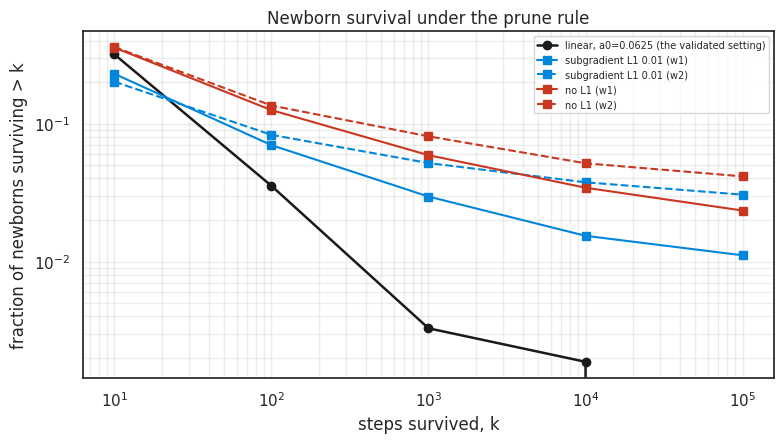

In [19]:
HORIZONS = (10, 100, 1_000, 10_000, 100_000)


def survival_fractions(traces, layer, horizons=HORIZONS):
    """Fraction of reset connections whose first prune-rule firing comes later than each horizon.

    Pools the useful and useless groups: the prune rule is not supposed to distinguish a *new*
    connection's usefulness, and both groups behave the same here. Connections that never fire
    count as surviving every horizon.
    """
    delays, never = [], 0.0
    n_total = 0
    for group in GROUPS:
        d, frac_never = time_to(traces, layer, group, key='prune_step')
        sel = _reset_selection(traces, layer, group)
        n = int(sel.sum()) * np.asarray(traces[f'final_prune_step_{layer}']).shape[0]
        delays.append(d)
        never += frac_never * n
        n_total += n
    delays = np.concatenate(delays)
    return [(never + (delays > k).sum()) / n_total for k in horizons]


rows = [{'setting': f'LINEAR (a0={LINEAR_INIT_LR:g})',
         'median life': float(np.median(linear_lifetimes)),
         **{f'>{k:,}': float((linear_lifetimes > k).mean()) for k in HORIZONS}}]
for key, spec in SPECS.items():
    for layer in LAYERS:
        delays, _ = time_to(TRACES[key], layer, USEFUL, key='prune_step')
        rows.append({'setting': f'{spec.label} ({layer})',
                     'median life': float(np.median(delays)) if len(delays) else np.nan,
                     **{f'>{k:,}': v for k, v in
                        zip(HORIZONS, survival_fractions(TRACES[key], layer))}})
survival_table = pd.DataFrame(rows)
print('Fraction of newborns surviving longer than k steps before the prune rule first fires:\n')
print(survival_table.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

plt.figure(figsize=(8, 4.6))
ax = plt.gca()
ax.plot(HORIZONS, [(linear_lifetimes > k).mean() for k in HORIZONS], marker='o', c='k', lw=1.8,
        label=f'linear, a0={LINEAR_INIT_LR:g} (the validated setting)')
for (key, spec), color in zip(SPECS.items(), get_color_palette(n=len(SPECS))):
    for layer, ls in zip(LAYERS, ('-', '--')):
        ax.plot(HORIZONS, survival_fractions(TRACES[key], layer), marker='s', ls=ls, color=color,
                label=f'{spec.label} ({layer})')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('steps survived, k')
ax.set_ylabel('fraction of newborns surviving > k')
ax.grid(True, alpha=0.35, which='both')
ax.legend(fontsize=7)
ax.set_title('Newborn survival under the prune rule')
plt.tight_layout()
plt.show()

### And it is not the step-size or the noise

The mechanism above says newborn survival should be governed by `alpha * E[x^2]` and be
independent of the residual power. The grid below varies the initial step-size over five orders of
magnitude and switches observation noise off entirely, on short L1-free runs. `final MSE` is
reported so that instability at the larger step-sizes is visible rather than silently distorting
the rest.

In [20]:
N_ABLATION_STEPS = 400_000 if not SMOKE_TEST else 20_000
N_ABLATION_SEEDS = 10 if not SMOKE_TEST else 2
N_ABLATION_SNAPSHOTS = 20
N_ABLATION_TRACES = 10
ABLATION_INIT_LRS = (1e-6, 1e-4, 1e-2)
ABLATION_NOISE_STDS = (1.0, 0.0)
ABLATION_L1 = 0.0    # L1-free, so the ablation isolates the step-size and the noise


def ablation_name(init_lr, noise_std):
    return _sweep_name(f'exp2_ablate_lr{init_lr:g}_noise{noise_std:g}'.replace('.', 'p'))


ABLATION = {}
for _init_lr in ABLATION_INIT_LRS:
    for _noise in ABLATION_NOISE_STDS:
        _spec = ExpSpec(
            name=ablation_name(_init_lr, _noise), label=f'a0={_init_lr:g}, noise={_noise:g}',
            fn=lambda n_seeds, n_steps, meta_lr, l1, reset_fraction, init_lr, noise_std:
                run_experiment(meta_lr, l1, reset_fraction, n_seeds, n_steps,
                               init_lr=init_lr, noise_std=noise_std,
                               n_snapshots=N_ABLATION_SNAPSHOTS, n_traces=N_ABLATION_TRACES))
        _grid = {'meta_lr': META_LR, 'l1': ABLATION_L1, 'reset_fraction': RESET_FRACTION,
                 'init_lr': _init_lr, 'noise_std': _noise}
        ABLATION[(_init_lr, _noise)] = (
            _spec, run_and_load(_spec, _grid, N_ABLATION_SEEDS, n_steps=N_ABLATION_STEPS,
                                n_traces=N_ABLATION_TRACES))

cfgs, runs = load_sweep_data()


def final_mse(sweep_name, final_fraction=FINAL_FRACTION):
    """Mean per-output MSE over the last `final_fraction` of the logged curve."""
    rdf = runs[sweep_name].dropna(subset=['loss'])
    if rdf.empty:
        return np.nan
    curve = rdf.groupby('step')['loss'].mean().sort_index()
    return float(curve.iloc[-max(1, int(final_fraction * len(curve))):].mean())


rows = []
for (init_lr, noise), (spec, traces) in ABLATION.items():
    mean_x2 = float(np.asarray(traces['mean_x2_w1']).mean())
    counts = np.asarray(traces['final_prune_count_w1'])
    active = np.asarray(masks['w1']) > 0
    delays, never = time_to(traces, 'w1', USEFUL, key='prune_step')
    rows.append({
        'init alpha': init_lr, 'noise': noise,
        'fires / conn / step': counts[:, active].mean() / N_ABLATION_STEPS,
        'median newborn lifetime': np.median(delays) if len(delays) else np.nan,
        'ever pruned': 1.0 - never,
        # 1 / (4 alpha E[x^2]) — predicted steps for h to clear its own jitter threshold.
        'predicted escape': 1.0 / (4 * init_lr * mean_x2),
        'final MSE': final_mse(spec.name),
    })
print('Input-layer useful connections, no L1, ' f'{N_ABLATION_STEPS:,} steps:\n')
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f'{v:.4g}'))

[I 2026-07-31 13:34:56,883] Using an existing study with name 'multi-geoff-experiment-2/exp2_ablate_lr1e-06_noise1' instead of creating a new one.


INFO:mlflow_sweeper.runner:Using existing parent MLflow run: 0853f569a6f04c8e931323b2c95025fb.


INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


[I 2026-07-31 13:34:57,012] Using an existing study with name 'multi-geoff-experiment-2/exp2_ablate_lr1e-06_noise0' instead of creating a new one.


INFO:mlflow_sweeper.runner:Using existing parent MLflow run: cbc4f68fbc3345cd96c9244075fd89ce.


...

INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


[I 2026-07-31 13:34:57,512] Using an existing study with name 'multi-geoff-experiment-2/exp2_ablate_lr0p01_noise0' instead of creating a new one.


INFO:mlflow_sweeper.runner:Using existing parent MLflow run: a1e1e3f71d074f1bb80c71f6d0857b68.


INFO:mlflow_sweeper.runner:Study is complete. No more trials to run.


Input-layer useful connections, no L1, 400,000 steps:

 init alpha  noise  fires / conn / step  median newborn lifetime  ever pruned  predicted escape  final MSE
      1e-06      1            0.0002087                        5       0.9855           7.5e+05      1.535
      1e-06      0             0.000278                        5       0.9744           7.5e+05     0.4688
     0.0001      1             0.000382                        5       0.9827              7500      1.502
     0.0001      0            0.0004571                        5       0.9701              7500     0.4479
       0.01      1             0.001526                        5       0.9921                75       1.49
       0.01      0             0.001394                        5       0.9791                75     0.4307


### Reading this

Two separate things were tangled together in the earlier reading, and they come apart cleanly.

**Newborn survival is the same everywhere — including in the linear setting.** Median newborn life
is 2–5 steps in every configuration measured here, and the survival curves sit on top of each other:

| | median life | >10 steps | >1,000 steps |
|---|---|---|---|
| linear, `a0 = 0.0625` (the validated setting) | 5 | 32% | 0.5% |
| network, subgradient L1 (w1) | 4 | 24% | 3.0% |
| network, no L1 (w1) | 5 | 37% | 5.9% |

So the rasters are telling the truth about newborns: nearly all of them are pruned within a handful
of steps, in both configurations. But the linear algorithm has exactly the same newborn mortality
and still worked well (final loss 0.029 against a mean-predictor 3.33), because generate-and-test
only needs the surviving tail — and the network's tail is in fact *fatter* than the linear one at
every horizon past 100 steps. Newborn churn is intrinsic to this rule, was measured and accepted in
the linear work ("fresh features start at exactly (w=0, h=0), inside the floor by construction... This
churn is accepted"), and is not evidence of anything wrong with the network, multi-GEOFF, or L1.

**What L1 changes is the churn of *established* connections.** Firings per connection per step:

| | rate | mean steps between firings |
|---|---|---|
| linear, `a0 = 0.0625` | 0.00085 | 1,172 |
| network, no L1 | 0.00046 (w1), 0.00065 (w2) | 1,544–2,197 |
| network, subgradient L1 | **0.069** (w1), **0.178** (w2) | **5.6–14.6** |

The prune test's first half asks whether the weight crossed zero, and Experiment 1 measured that
weights in the subgradient-L1 limit cycle flip sign on ~99% of steps; the same cycle keeps `h` small,
satisfying the second half. So with L1 every connection — settled ones included — is prunable every
few steps, 100–400x the linear rate. Without L1 the network sits just inside the linear regime.

**And "96–99% would be pruned" was the wrong statistic for either question.** It is an
ever-in-750k-steps measure: at a rate of 0.0005/step it is ~100% by construction, so it reads ~98%
in every configuration and cannot separate the two regimes above. The survival curve answers the
newborn question and the per-step rate answers the churn question; the ever-statistic answers
neither.

The ablation confirms the newborn mechanism is a property of the rule rather than of this problem:
varying `a0` over four orders of magnitude and removing observation noise entirely leaves newborn
lifetime at 5 steps throughout, exactly as `|h| / J_h = 2*sqrt(alpha n E[x^2])` predicts once you
notice the residual power cancels. Only the overall rate tracks `a0`, rising from 0.0002 to 0.0015
across that range — which is why the linear setting's much larger step-size puts it slightly above
the no-L1 network.